## **Modelos de Regresión**

In [ ]:
import numpy as np  # Importa la librería NumPy para operaciones matemáticas avanzadas.
import matplotlib.pyplot as plt  # Importa Matplotlib para visualización de datos.
import pandas as pd  # Importa pandas para manipulación y análisis de datos.
import seaborn as sns # Importa seaborn para la visualizacion de datos
import warnings # Importa warnings para las advertencia

# Importa funciones de Scikit-learn para dividir el conjunto de datos y aplicar regresión lineal.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Importa la librería Statsmodels para ajustar modelos de regresión con más opciones estadísticas.
import statsmodels.formula.api as smf

In [ ]:
df = pd.read_csv(r'_data\dataml\housing.csv')

# Mostrar las primeras filas del conjunto de datos
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Las variables del conjunto de datos son

- **longitude**: Coordenada de longitud de la ubicación de la vivienda.
- **latitude**: Coordenada de latitud de la ubicación de la vivienda.
- **housing_median_age**: Edad media de las casas en la zona.
- **total_rooms**: Número total de habitaciones en las casas de la zona.
- **total_bedrooms**: Número total de dormitorios en las casas de la zona.
- **population**: Población total de la zona.
- **households**: Número total de hogares en la zona.
- **median_income**: Ingreso medio de los hogares en la zona (en decenas de miles de dólares).
- **median_house_value**: Valor medio de las casas en la zona (en dólares).
- **ocean_proximity**: Proximidad del área al océano.

In [6]:
# Mostrar las ultimas filas del conjunto de datos
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [7]:
# Información de las variables
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
# dimensión del conjunto de datos
df.shape

(20640, 10)

#### 3. **Datos faltantes o NANs**

In [9]:
missing_values = df.isna().sum()
total_rows = df.shape[0]

missing_vars = missing_values[missing_values > 0]

missing_info_df = pd.DataFrame({
    'Datos faltantes': missing_vars,
    'Porcentaje (%)': round((missing_vars / total_rows) * 100,2)})

missing_info_df

,Datos faltantes,Porcentaje (%)
total_bedrooms,207,1.0


#### 4. **Resumen estadístico.**

* Variable de objetivo con las predictoras (numéricas)

In [10]:
# descriptiva
pd.set_option('display.precision', 2)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20433.0,537.87,421.39,1.00,296.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


* Variable predictora (categórica)

In [11]:
# Descriptivo de una sola variable categórica solo conteo
conteo = df['ocean_proximity'].value_counts()

# Descriptivo de una sola variable categórica solo proporcion
proporciones = df['ocean_proximity'].value_counts(normalize=True)

# Combinar los resultados en un solo DataFrame
resultado = pd.DataFrame({
    'Conteo': conteo,
    'Proporción': proporciones
})

# imprimir
pd.set_option('display.precision', 4)
print(resultado)

                 Conteo  Proporción
ocean_proximity                    
<1H OCEAN          9136      0.4426
INLAND             6551      0.3174
NEAR OCEAN         2658      0.1288
NEAR BAY           2290      0.1109
ISLAND                5      0.0002


#### 5. **Visualización del conjunto de datos**

* Variables numéricas

Columna:  longitude
Asimetría (Skew): -0.3
Curtosis: -1.33


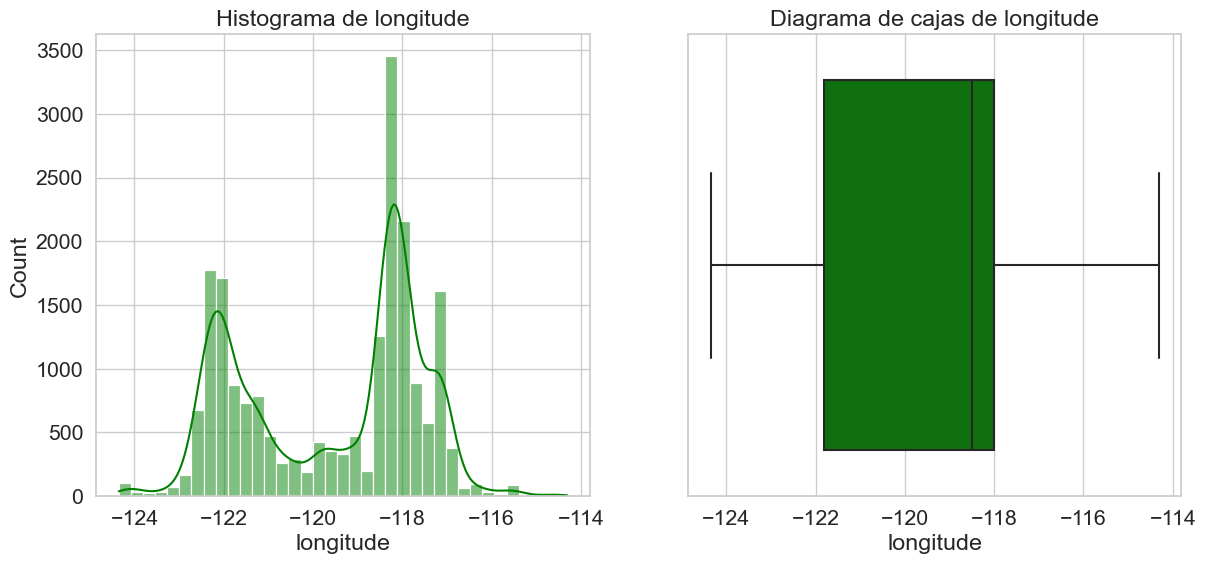

Columna:  latitude
Asimetría (Skew): 0.47
Curtosis: -1.12


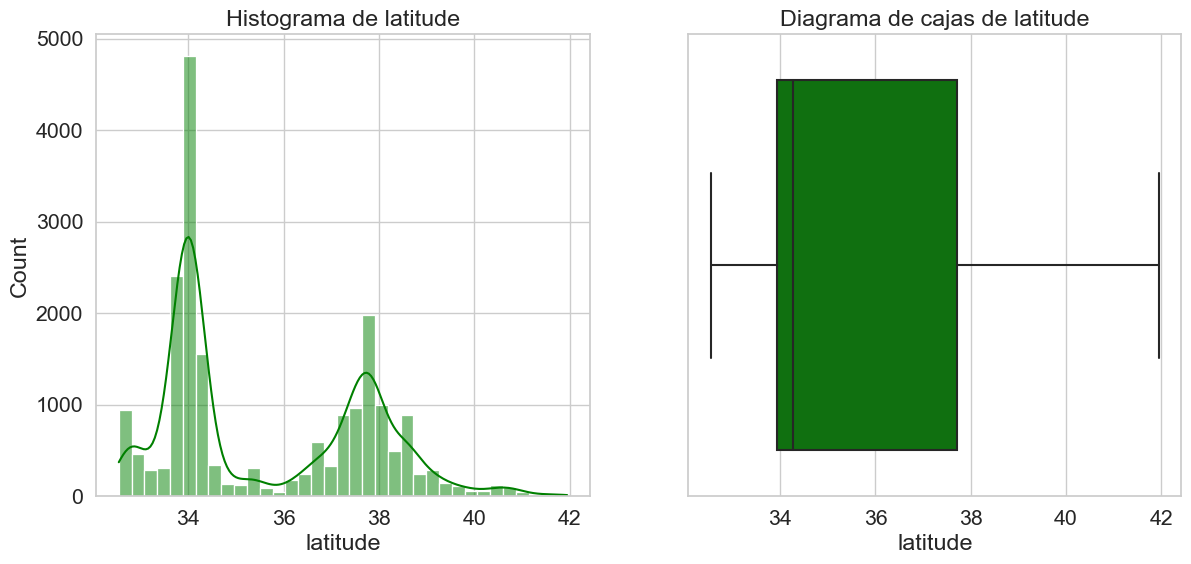

Columna:  housing_median_age
Asimetría (Skew): 0.06
Curtosis: -0.8


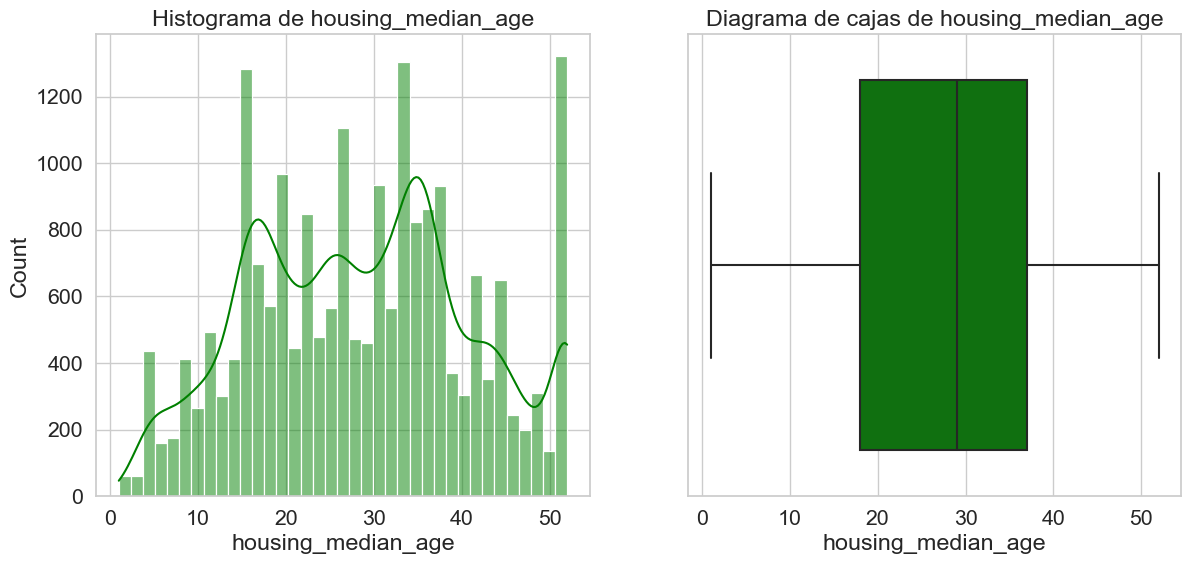

Columna:  total_rooms
Asimetría (Skew): 4.15
Curtosis: 32.63


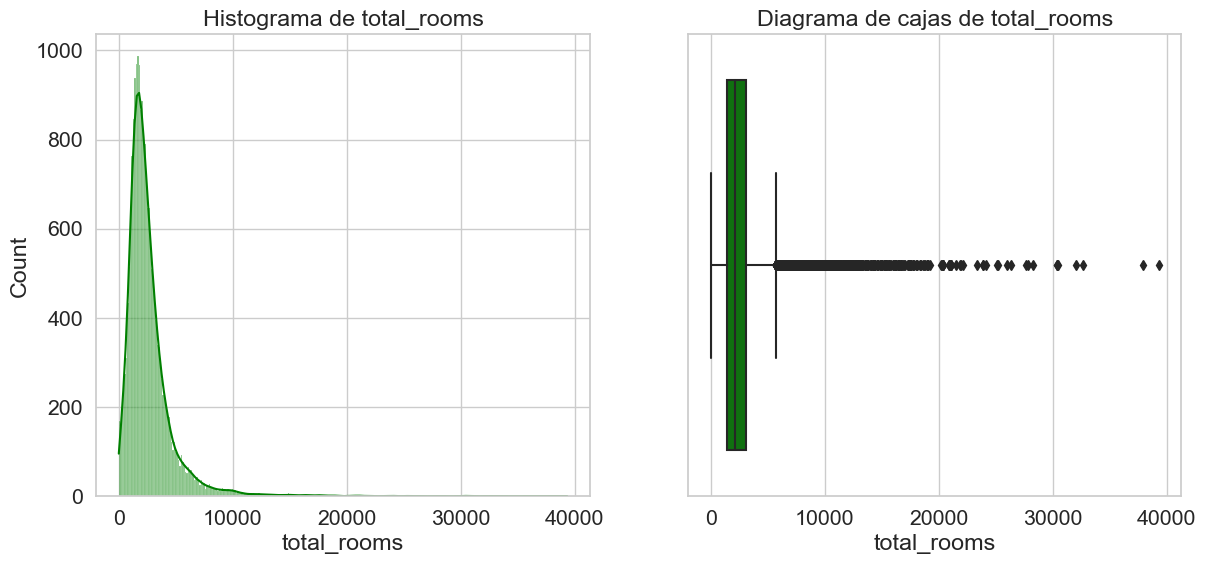

Columna:  total_bedrooms
Asimetría (Skew): 3.46
Curtosis: 21.99


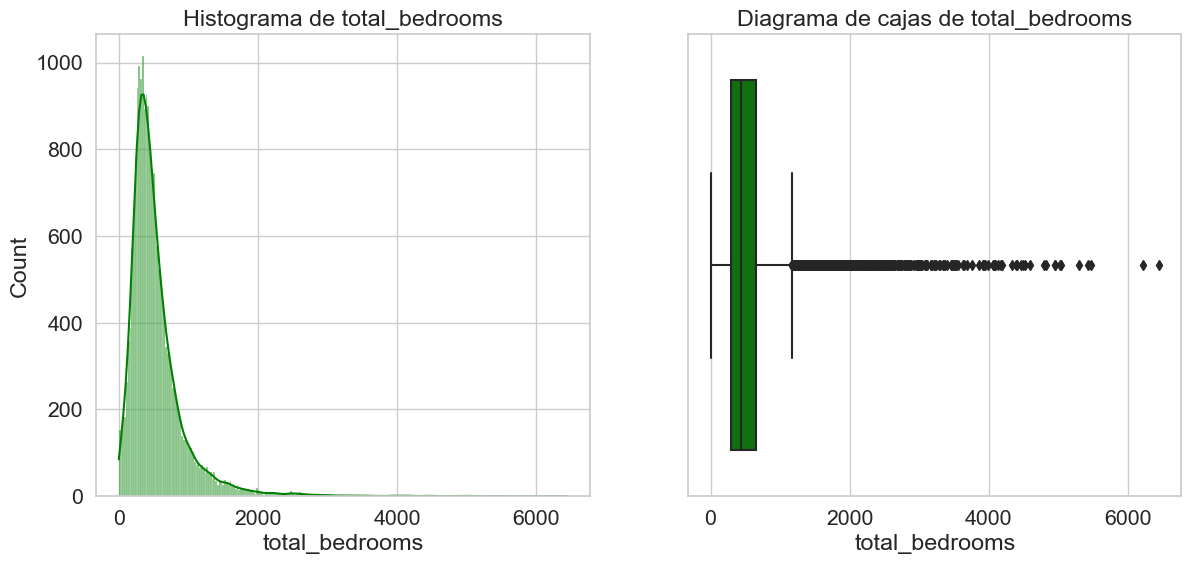

Columna:  population
Asimetría (Skew): 4.94
Curtosis: 73.55


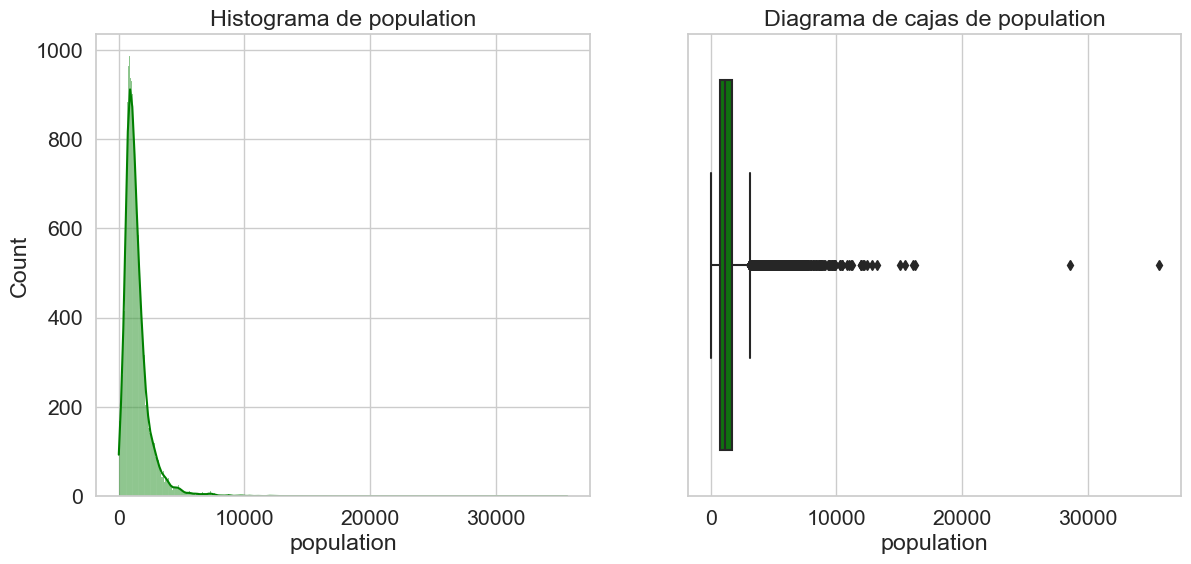

Columna:  households
Asimetría (Skew): 3.41
Curtosis: 22.06


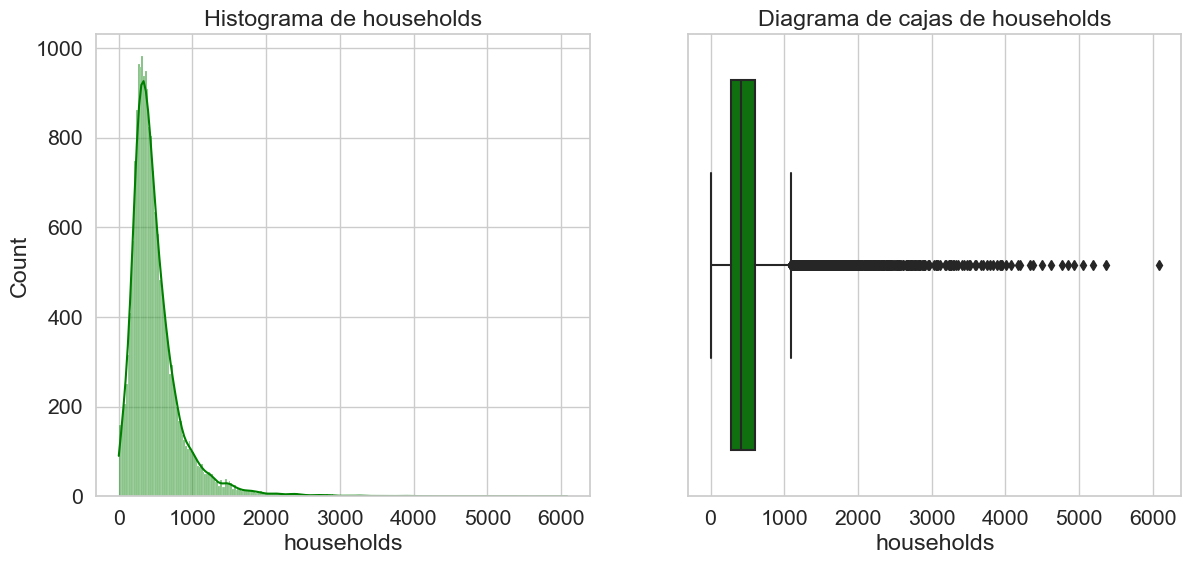

Columna:  median_income
Asimetría (Skew): 1.65
Curtosis: 4.95


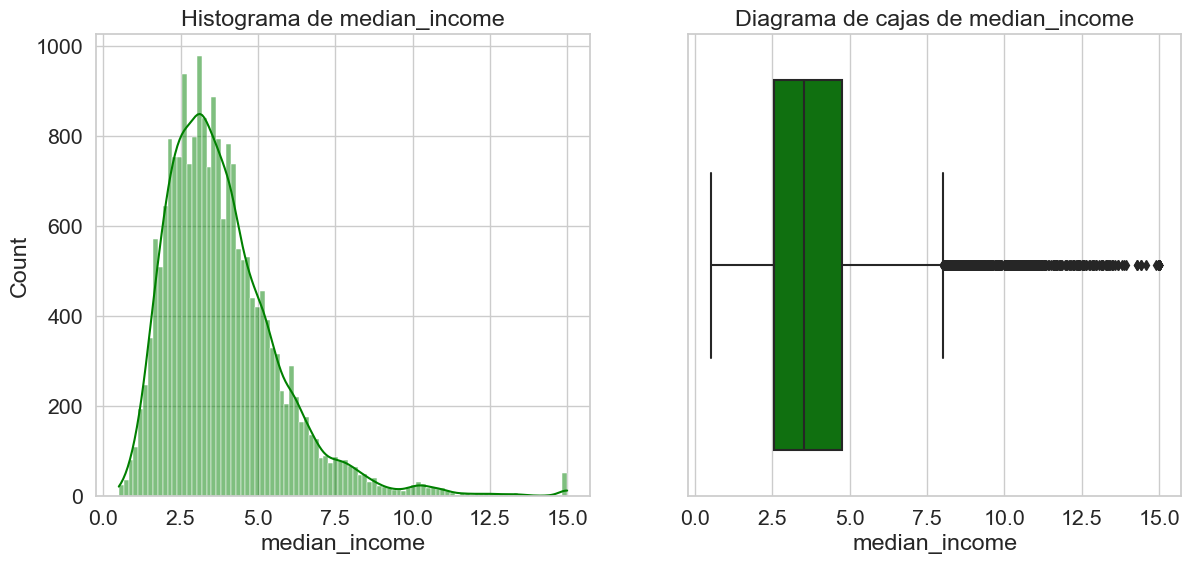

Columna:  median_house_value
Asimetría (Skew): 0.98
Curtosis: 0.33


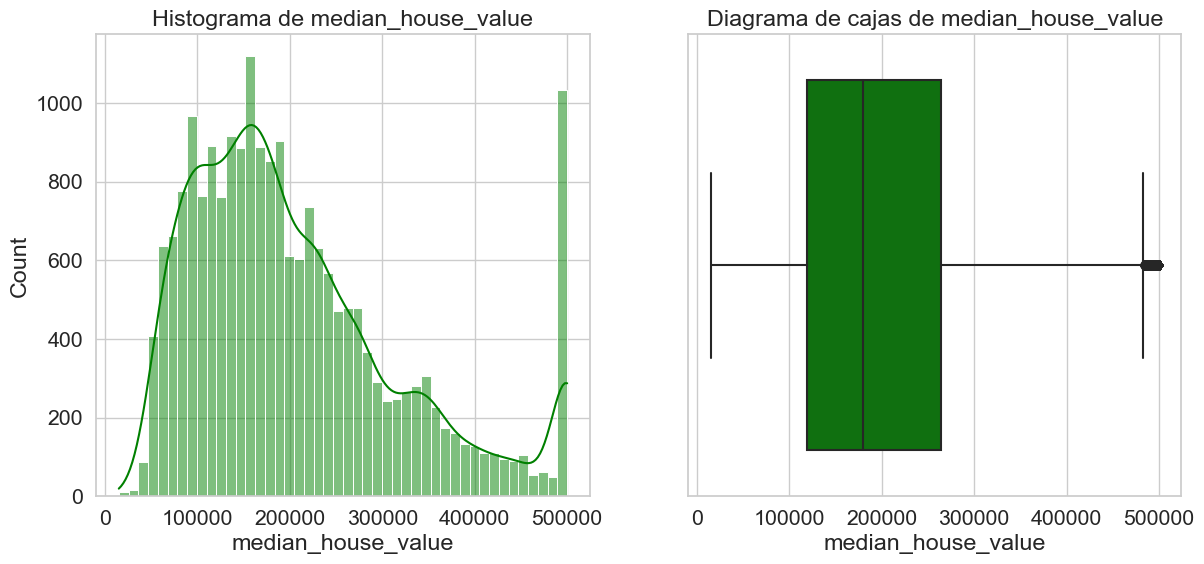

In [13]:
# Ignorar advertencias de futuras versiones
warnings.filterwarnings('ignore') 

# Extrayendo las variables numéricas del dataset
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Ajustar el estilo de Seaborn y el color verde para los gráficos
sns.set(style="whitegrid", font_scale=1.4)

# Crear gráficos de histograma con densidad (KDE) y diagrama de cajas con asimetría y curtosis en color verde
for column in numerical_columns:
    # Imprimir asimetría y curtosis
    print('Columna: ', column)
    print('Asimetría (Skew):', round(df[column].skew(), 2))
    print('Curtosis:', round(df[column].kurtosis(), 2))
    
    # Crear figura
    plt.figure(figsize=(14, 6))
    
    # Subplot para el histograma con KDE (curva de densidad)
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True, color='green')
    plt.title(f'Histograma de {column}')
    
    # Subplot para el diagrama de cajas
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[column], color='green')
    plt.title(f'Diagrama de cajas de {column}')
    
    # Mostrar la figura con los gráficos
    plt.show()

* Variable categórica

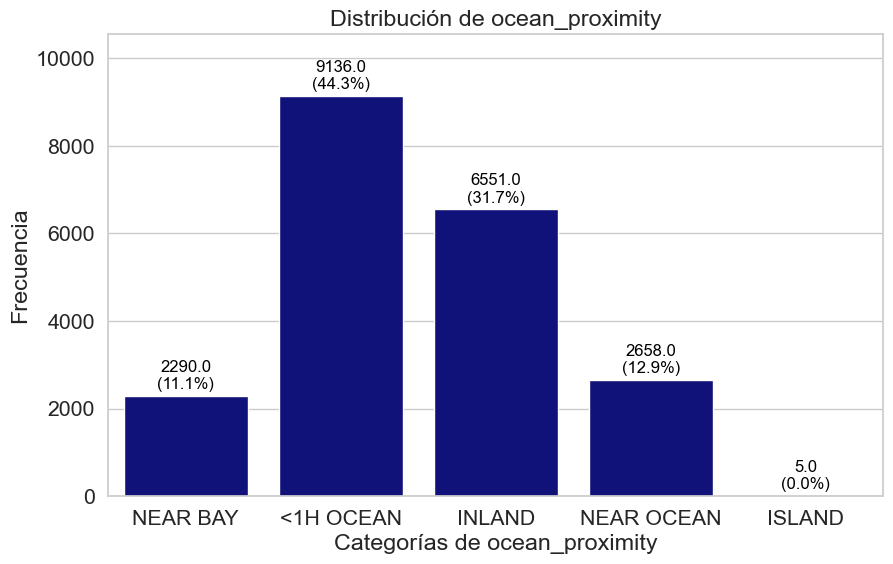

In [45]:
# Ajustar el gráfico aumentando el eje Y para mayor visibilidad de las etiquetas
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='ocean_proximity', data=df2, color='darkblue')

# Añadir el conteo y el porcentaje encima de cada barra
total = len(df2)  # Número total de registros
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{count}\n({percentage:.1f}%)', 
                (p.get_x() + p.get_width() / 2., count), 
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

# Ajustar el límite del eje Y
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

# Personalización del gráfico
plt.title('Distribución de ocean_proximity')
plt.xlabel('Categorías de ocean_proximity')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)  # Rotar las etiquetas para mejor visibilidad
plt.show()

* Gráfica bivariada

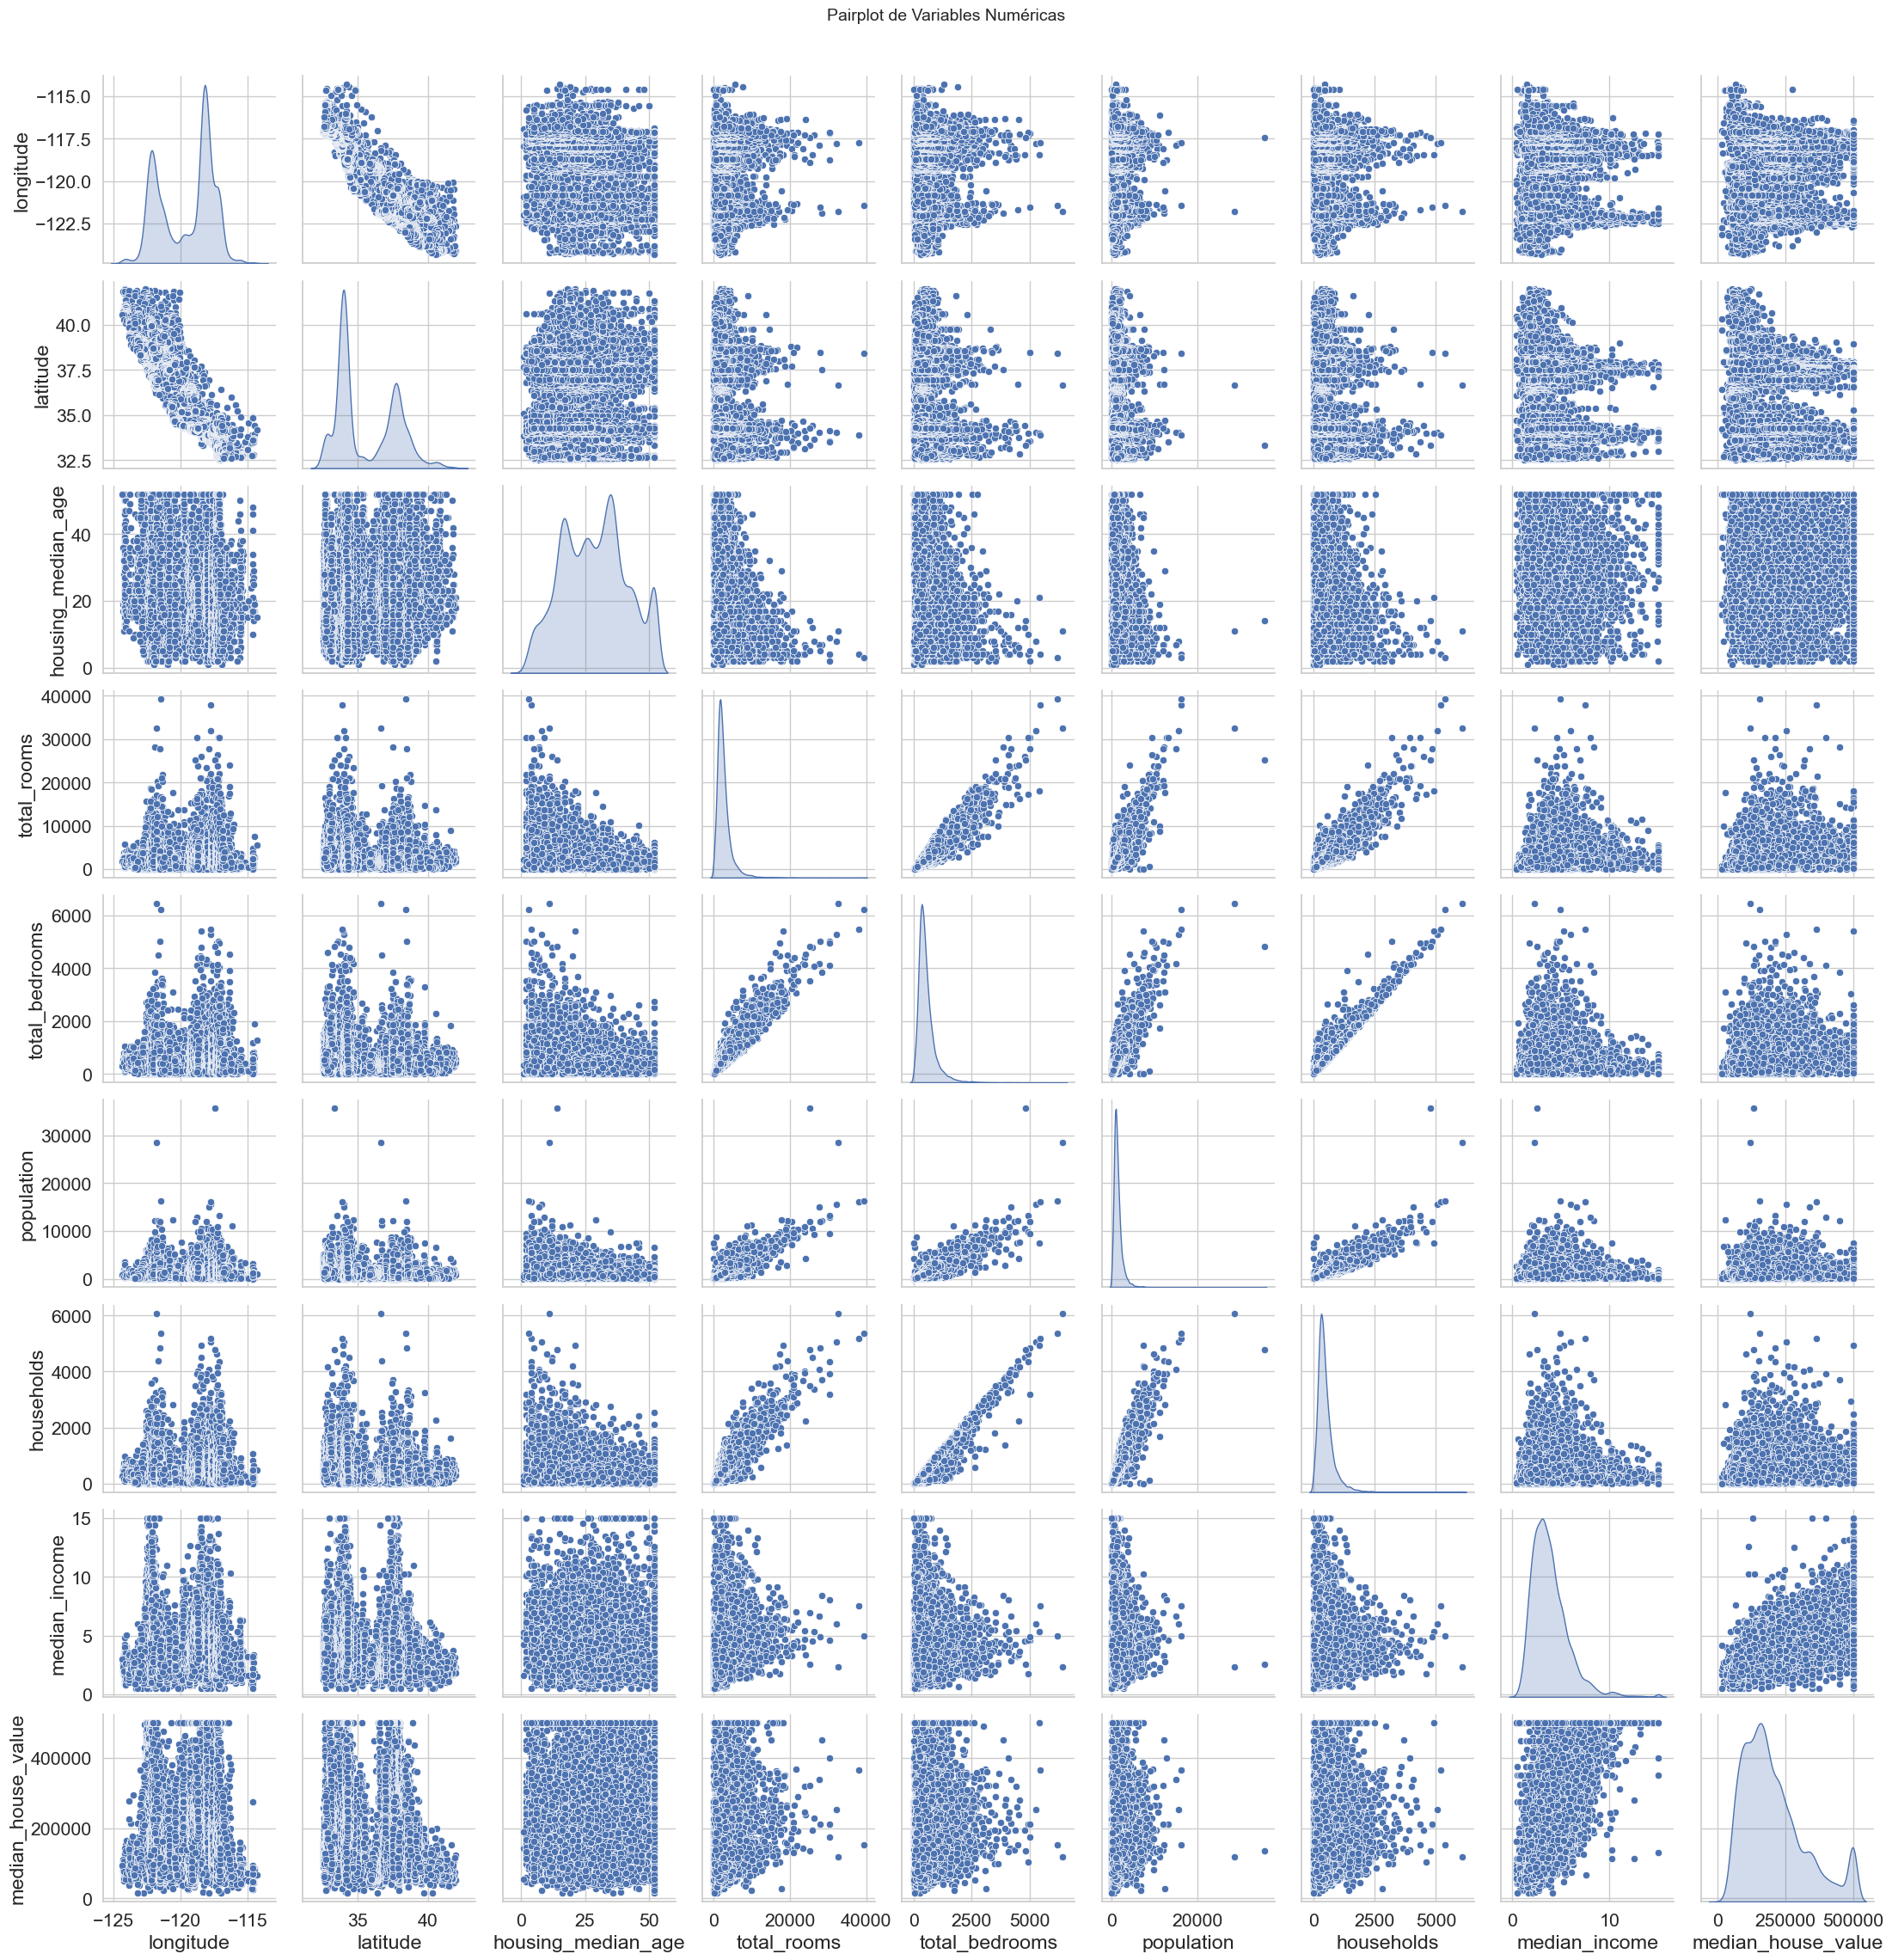

In [14]:
# Removiendo la variable categórica
df_cor  = df.drop(columns=['ocean_proximity'])

# Realizar el pairplot para las variables numéricas sin usar 'hue' ya que no tenemos una variable categórica adecuada
sns.pairplot(data=df_cor, diag_kind='kde', palette='viridis')
plt.suptitle('Pairplot de Variables Numéricas', y=1.02, fontsize=14)
plt.show()

#### 6. **Correlaciones**

* Es importante garantizar la ausencia de relación entre atríbutos, por tal razón lo utilizaremos la función `corr(method='spearman')` para verificar que se cumpla esta condición.

In [15]:
# correlation
pd.set_option('display.precision', 4)
df_cor.corr(method='spearman')

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.0000,-0.8792,-0.1508,0.0401,0.0639,0.1235,0.0600,-0.0099,-0.0697
latitude,-0.8792,1.0000,0.0324,-0.0184,-0.0566,-0.1236,-0.0743,-0.0880,-0.1657
housing_median_age,-0.1508,0.0324,1.0000,-0.3572,-0.3065,-0.2839,-0.2820,-0.1473,0.0749
total_rooms,0.0401,-0.0184,-0.3572,1.0000,0.9150,0.8162,0.9067,0.2713,0.2060
total_bedrooms,0.0639,-0.0566,-0.3065,0.9150,1.0000,0.8709,0.9756,-0.0062,0.0863
population,0.1235,-0.1236,-0.2839,0.8162,0.8709,1.0000,0.9039,0.0063,0.0038
households,0.0600,-0.0743,-0.2820,0.9067,0.9756,0.9039,1.0000,0.0303,0.1127
median_income,-0.0099,-0.0880,-0.1473,0.2713,-0.0062,0.0063,0.0303,1.0000,0.6768
median_house_value,-0.0697,-0.1657,0.0749,0.2060,0.0863,0.0038,0.1127,0.6768,1.0000


* **`median_income`** tiene la mayor correlación positiva con **`median_house_value`** (0.6768).
* **`total_rooms`** y **`total_bedrooms`** están fuertemente correlacionados (0.9150).
* La correlación entre **`median_house_value`** y otras variables como **`total_rooms`**, **`total_bedrooms`** o **`population`** es baja.
* Hay una correlación negativa entre **`latitude`** y **`median_house_value`** (-0.1657), sugiriendo precios más altos al sur.
* **`population`** no está correlacionada significativamente con **`median_house_value`** (0.0038).

* Ahora, realicemos la gráfica de correlación

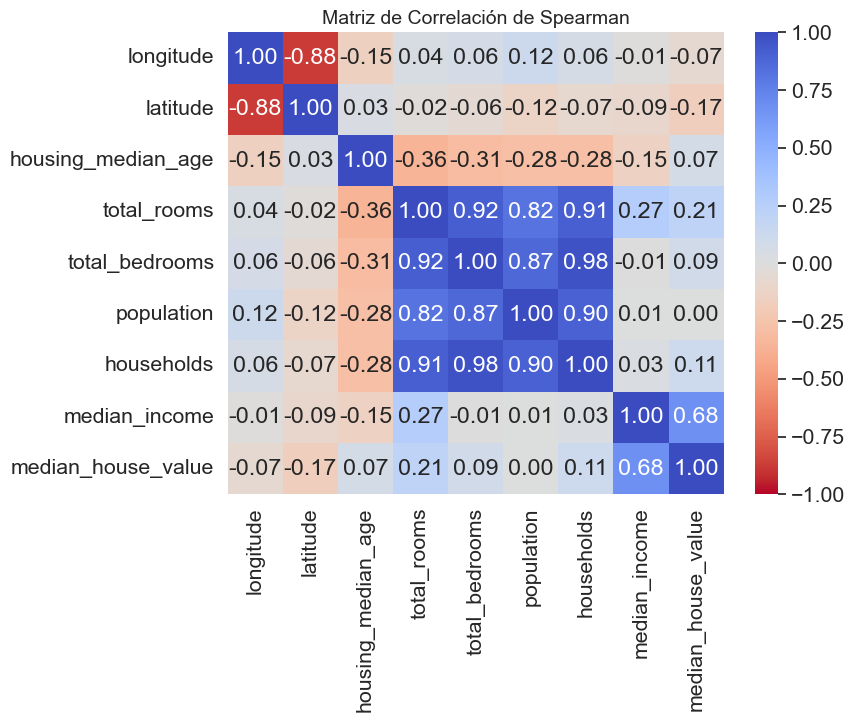

In [16]:
# Calculating the correlation using the Spearman method
correlation_matrix = df_cor.corr(method='spearman')

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm_r', fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlación de Spearman', fontsize=14)
plt.show()

* Calculemos el VIF para evitar la multicolinealidad de las variables

In [40]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Separar características independientes (X) eliminando el target
X_completo = df.drop(columns=['median_house_value'])

# 2. Identificar columnas categóricas y numéricas
col_categoricas = ['ocean_proximity']
col_numericas = X_completo.select_dtypes(include=['float64', 'int64']).columns.tolist()

# 3. Codificar la variable categórica para que sea procesable por el VIF
encoder_ini = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder_ini.fit_transform(X_completo[col_categoricas])
nombres_cat = encoder_ini.get_feature_names_out(col_categoricas)

# 4. Concatenar manteniendo consistencia de índices
X_cat_df = pd.DataFrame(X_cat_encoded, columns=nombres_cat, index=X_completo.index)
X_unificado = pd.concat([X_completo[col_numericas], X_cat_df], axis=1)

# 5. Imputación rápida temporal (El cálculo de VIF no tolera valores nulos)
X_unificado['total_bedrooms'] = X_unificado['total_bedrooms'].fillna(X_unificado['total_bedrooms'].mean())

# 6. Algoritmo de cálculo del VIF
X_vif = X_unificado.copy()
X_vif['intercept'] = 1  # statsmodels requiere explícitamente agregar una constante (intersección)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Filtrar el intercepto y ordenar los resultados de mayor a menor peligro
vif_data = vif_data[vif_data["Variable"] != 'intercept'].sort_values(by="VIF", ascending=False)

print("=== VIF INICIAL (DATOS COMPLETOS ANTES DE TODO) ===")
print(vif_data.to_string(index=False))

=== VIF INICIAL (DATOS COMPLETOS ANTES DE TODO) ===
                  Variable     VIF
                households 28.6378
            total_bedrooms 27.5036
                  latitude 19.9303
                 longitude 18.0347
               total_rooms 12.3777
                population  6.3450
    ocean_proximity_INLAND  2.8543
             median_income  1.7429
  ocean_proximity_NEAR BAY  1.5657
        housing_median_age  1.3219
ocean_proximity_NEAR OCEAN  1.1972
    ocean_proximity_ISLAND  1.0020


Para solucionar la alarma roja del VIF sin perder la información valiosa de tus datos, haremos ingeniería de características (Feature Engineering) para transformar el bloque redundante en variables relativas.

Podemos reemplazar las columnas problemáticas creando estas tres nuevas variables:

* `rooms_per_household = total_rooms / households` (Promedio de cuartos por casa).

* `bedrooms_per_room = total_bedrooms / total_rooms` (Densidad de dormitorios por cuarto).

* `population_per_household = population / households` (Promedio de habitantes por hogar).

In [41]:
# Función auxiliar para calcular el VIF (statsmodels requiere agregar una constante/intercepto)
def calcular_vif(df_features):
    X_vif = df_features.copy()
    X_vif['intercept'] = 1  
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    return vif_data[vif_data["Variable"] != 'intercept'].sort_values(by="VIF", ascending=False)

# =========================================================================
# VIF FINAL (Con tus columnas transformadas)
# =========================================================================
df_fe = df.copy()
df_fe['rooms_per_household']      = df_fe['total_rooms']    / df_fe['households']
df_fe['bedrooms_per_room']        = df_fe['total_bedrooms'] / df_fe['total_rooms']
df_fe['population_per_household'] = df_fe['population']     / df_fe['households']

# Removemos las variables originales que causaban la colinealidad masiva
X_transformado = df_fe.drop(columns=['median_house_value', 'total_rooms', 'total_bedrooms', 'population', 'households'])
col_numericas_trans = X_transformado.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Procesamos categorías e imputamos nulos sobre las nuevas columnas
encoder_fin = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_cat_fin = encoder_fin.fit_transform(X_transformado[col_categoricas])
X_enc_fin = pd.concat([X_transformado[col_numericas_trans], pd.DataFrame(X_cat_fin, columns=encoder_fin.get_feature_names_out(col_categoricas))], axis=1)
X_enc_fin['bedrooms_per_room'] = X_enc_fin['bedrooms_per_room'].fillna(X_enc_fin['bedrooms_per_room'].mean())

print("\n=== VIF FINAL (CON INGENIERÍA DE CARACTERÍSTICAS APLICADA) ===")
print(calcular_vif(X_enc_fin).to_string(index=False))


=== VIF FINAL (CON INGENIERÍA DE CARACTERÍSTICAS APLICADA) ===
                  Variable     VIF
                  latitude 20.1999
                 longitude 18.2148
    ocean_proximity_INLAND  2.8967
             median_income  2.0411
         bedrooms_per_room  1.9210
  ocean_proximity_NEAR BAY  1.5456
       rooms_per_household  1.3181
ocean_proximity_NEAR OCEAN  1.1841
        housing_median_age  1.1648
  population_per_household  1.0024
    ocean_proximity_ISLAND  1.0016


#### 7. **Construcción del modelo de regresión**

In [45]:
import pandas as pd # Para la manipulación y carga de los datos (DataFrames)
from sklearn.model_selection import train_test_split # Para separar en Train y Test (evita data leakage)
from sklearn.preprocessing import OneHotEncoder, StandardScaler # Para convertir texto categórico en números (0 y 1) y se estandarizan las variables numéricas
from sklearn.experimental import enable_iterative_imputer # Obligatorio para activar el imputador avanzado
from sklearn.impute import IterativeImputer # Para llenar nulos mediante modelos de regresión (MICE)
from sklearn.compose import ColumnTransformer # Para aplicar transformaciones diferentes a columnas distintas

# =========================================================================
# 1. CARGA DE DATOS E INGENIERÍA DE CARACTERÍSTICAS
# =========================================================================
df = pd.read_csv(r"C:\Documentos\Books_CienciaDatos\DSTripleA\docs\_data\dataml\housing.csv")

# Creamos las tasas relativas que reducen la multicolinealidad masiva
df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']  # Hereda los nulos
df['population_per_household'] = df['population']     / df['households']

# Removemos los totales acumulados (problemáticos) y aislamos el target
X = df.drop(columns=['median_house_value', 'total_rooms', 'total_bedrooms', 'population', 'households'])
y = df['median_house_value']
     

# =========================================================================
# PASO 2: SEPARACIÓN EN ENTRENAMIENTO Y TEST (Train/Test Split)
# =========================================================================
# Hacemos esto primero para blindarnos completamente contra el Data Leakage
# Divide los datos en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Características predictoras (variables independientes)
    y,                  # Variable objetivo (el precio de las casas a predecir)
    test_size=0.2,      # Proporción del 20% reservada para el conjunto de prueba
    shuffle=True,       # Mezcla los datos aleatoriamente antes de dividirlos
    random_state=42     # Semilla fija para que la división sea reproducible al replicar el código
)

In [46]:
# 1. Calcular el tamaño (filas, columnas) de los conjuntos de características
print("Entrenamiento (X_train):", X_train.shape)
print("Prueba (X_test):", X_test.shape)

# 2. Calcular el tamaño (filas,) de los conjuntos de la variable objetivo
print("Target Entrenamiento (y_train):", y_train.shape)
print("Target Prueba (y_test):", y_test.shape)

# 3. Verificar que las proporciones y promedios del precio sean similares
print("\nPromedio del precio en Entrenamiento:", y_train.mean())
print("Promedio del precio en Prueba:", y_test.mean())

Entrenamiento (X_train): (16512, 8)
Prueba (X_test): (4128, 8)
Target Entrenamiento (y_train): (16512,)
Target Prueba (y_test): (4128,)

Promedio del precio en Entrenamiento: 207194.6937378876
Promedio del precio en Prueba: 205500.30959302327


In [47]:
# =========================================================================
# PASO 3: CODIFICACIÓN CATEGÓRICA CON ONEHOTENCODER
# =========================================================================
# Identificamos las columnas por su tipo
col_categoricas = ['ocean_proximity']
col_numericas = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# --- A. Codificación Categórica (OneHotEncoder) ---
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Ajustamos en Train y transformamos ambos conjuntos
X_train_cat = encoder.fit_transform(X_train[col_categoricas])
X_test_cat = encoder.transform(X_test[col_categoricas])

nombres_cat = encoder.get_feature_names_out(col_categoricas)

X_train_encoded = pd.concat([X_train[col_numericas], pd.DataFrame(X_train_cat, columns=nombres_cat, index=X_train.index)], axis=1)
X_test_encoded = pd.concat([X_test[col_numericas], pd.DataFrame(X_test_cat, columns=nombres_cat, index=X_test.index)], axis=1)

In [48]:
# Ver las primeras 5 filas del conjunto de entrenamiento transformado
X_train_encoded.head()

,longitude,latitude,housing_median_age,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,-117.03,32.71,33.0,3.2596,5.0177,0.2006,3.6918,0.0,0.0,0.0,1.0
8267,-118.16,33.77,49.0,3.8125,4.4735,0.2327,1.7381,0.0,0.0,0.0,1.0
17445,-120.48,34.66,4.0,4.1563,5.6458,0.1745,2.7232,0.0,0.0,0.0,1.0
14265,-117.11,32.69,36.0,1.9425,4.0028,0.2583,3.9944,0.0,0.0,0.0,1.0
2271,-119.80,36.78,43.0,3.5542,6.2684,0.1809,2.3000,1.0,0.0,0.0,0.0


In [49]:
# Ver las primeras 5 filas del conjunto de prueba transformado
X_test_encoded.head()

,longitude,latitude,housing_median_age,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
20046,-119.01,36.06,25.0,1.6812,4.1922,NaN,3.8774,1.0,0.0,0.0,0.0
3024,-119.46,35.14,30.0,2.5313,5.0394,NaN,2.6798,1.0,0.0,0.0,0.0
15663,-122.44,37.80,52.0,3.4801,3.9772,NaN,1.3603,0.0,0.0,1.0,0.0
20484,-118.72,34.28,17.0,5.7376,6.1636,NaN,3.4444,0.0,0.0,0.0,0.0
9814,-121.93,36.62,34.0,3.7250,5.4930,NaN,2.4836,0.0,0.0,0.0,1.0


In [51]:
# --- B. Imputación Multivariada (IterativeImputer) ---
# Estima los nulos en 'bedrooms_per_room' basándose en las correlaciones del Train
imputer = IterativeImputer(random_state=42, max_iter=10)

X_train_imputed = imputer.fit_transform(X_train_encoded)
X_test_imputed = imputer.transform(X_test_encoded)

# (Opcional) Convertir de nuevo a DataFrame para verificar que todo esté limpio y ordenado
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=X_train_encoded.columns)
X_train_imputed_df.head()

,longitude,latitude,housing_median_age,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-117.03,32.71,33.0,3.2596,5.0177,0.2006,3.6918,0.0,0.0,0.0,1.0
1,-118.16,33.77,49.0,3.8125,4.4735,0.2327,1.7381,0.0,0.0,0.0,1.0
2,-120.48,34.66,4.0,4.1563,5.6458,0.1745,2.7232,0.0,0.0,0.0,1.0
3,-117.11,32.69,36.0,1.9425,4.0028,0.2583,3.9944,0.0,0.0,0.0,1.0
4,-119.80,36.78,43.0,3.5542,6.2684,0.1809,2.3000,1.0,0.0,0.0,0.0


In [52]:
# --- C. Estandarización Final (StandardScaler) ---
# Centra las variables a media 0 y varianza 1 para una óptima convergencia de la regresión
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_train_scaled_df.head()

,longitude,latitude,housing_median_age,median_income,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,1.2726,-1.3728,0.3485,-0.3262,-0.1749,-0.2118,0.0514,-0.6806,-0.0156,-0.3556,2.6298
1,0.7092,-0.8767,1.6181,-0.0358,-0.4028,0.3422,-0.1174,-0.6806,-0.0156,-0.3556,2.6298
2,-0.4476,-0.4601,-1.9527,0.1447,0.0882,-0.6617,-0.0323,-0.6806,-0.0156,-0.3556,2.6298
3,1.2327,-1.3822,0.5865,-1.0179,-0.6000,0.7830,0.0775,-0.6806,-0.0156,-0.3556,2.6298
4,-0.1086,0.5321,1.1420,-0.1715,0.3490,-0.5504,-0.0688,1.4693,-0.0156,-0.3556,-0.3803


### **Regresión lineal multiple**

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================================
# Modelo con Validacion cruzada (Cross-Validation)
# # =========================================================================
modelo_lr = LinearRegression()

# Evaluamos el modelo en el set de entrenamiento usando validación cruzada de 5 pliegues
cv_scores_rl = cross_val_score(modelo_lr, 
                            X_train_scaled, 
                            y_train, 
                            scoring='neg_root_mean_squared_error', # Métrica: RMSE en negativo
                            cv=5,                                  # 5 divisiones (Folds)
                            n_jobs=-1)                             # Usa todos los núcleos del CPU

rmse_cv_promedio_rl = -cv_scores_rl.mean()
rmse_cv_desv_rl = cv_scores_rl.std()

# =========================================================================
# AJUSTE FINAL Y EVALUACIÓN EN TEST
# =========================================================================

modelo_lr.fit(X_train_scaled, y_train)
y_pred = modelo_lr.predict(X_test_scaled)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print("=== MÉTRICAS DEL MODELO BASE ===")
print(f"RMSE Promedio (Validación Cruzada): ${rmse_cv_promedio_rl:,.2f}")
print(f"Desviación RMSE (Validación Cruzada): ${rmse_cv_desv_rl:,.2f}")
print(f"RMSE Final (Conjunto de Prueba):    ${rmse_test:,.2f}")
print(f"R² Final (Conjunto de Prueba):       {r2_test:.4f}")

=== MÉTRICAS DEL MODELO BASE ===
RMSE Promedio (Validación Cruzada): $70,628.68
Desviación RMSE (Validación Cruzada): $729.29
RMSE Final (Conjunto de Prueba):    $71,916.94
R² Final (Conjunto de Prueba):       0.6053


Usando un `pipeline` nos queda:

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# =========================================================================
# 1. CARGA DE DATA E INGENIERÍA DE CARACTERÍSTICAS
# =========================================================================
df = pd.read_csv(r'C:\Documentos\Books_CienciaDatos\DSTripleA\docs\_data\dataml\housing.csv')

df['rooms_per_household']      = df['total_rooms']    / df['households']
df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']     / df['households']

X = df.drop(columns=['median_house_value', 'total_rooms', 'total_bedrooms', 'population', 'households'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# Identificamos las columnas numéricas y categóricas que alimentarán el pipeline
col_categoricas = ['ocean_proximity']
col_numericas = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()

# =========================================================================
# 2. CONSTRUCCIÓN DEL PIPELINE COMPLETO
# =========================================================================

# Diseñamos el preprocesador por columnas: las categóricas se vuelven binarias
preprocesador = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), col_categoricas)
    ],
    remainder='passthrough' # Mantiene intactas las columnas numéricas para el siguiente paso
)

# Creamos el pipeline unificado con los pasos secuenciales ordenados matemáticamente
pipeline_lr = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10), # Imputación sobre toda la matriz numérica resultante
    StandardScaler(),                               # Estandarización final a media 0 y varianza 1
    LinearRegression()                              # El estimador / modelo final sin penalización
)

# =========================================================================
# 3. VALIDACIÓN CRUZADA Y EVALUACIÓN USANDO EL PIPELINE
# =========================================================================

# Evaluamos la estabilidad usando K-Fold CV directamente sobre el pipeline completo
cv_scores_rl = cross_val_score(pipeline_lr, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)
rmse_cv_promedio_rl = -cv_scores_rl.mean()
rmse_cv_desv_rl = cv_scores_rl.std()

# Ajustamos (entrenamos) el pipeline completo en el conjunto de entrenamiento original
pipeline_lr.fit(X_train, y_train)

# --- ADAPTACIÓN: Evaluamos utilizando el pipeline sobre el conjunto de Entrenamiento ---
y_pred_train_rl = pipeline_lr.predict(X_train)
rmse_train_rl = np.sqrt(mean_squared_error(y_train, y_pred_train_rl))
r2_train_rl = r2_score(y_train, y_pred_train_rl)

# Predecimos directamente enviando los datos de prueba crudos
y_pred_rl = pipeline_lr.predict(X_test)

# Cálculo de métricas sobre el conjunto de prueba
rmse_test_rl = np.sqrt(mean_squared_error(y_test, y_pred_rl))
r2_test_rl = r2_score(y_test, y_pred_rl)

# =========================================================================
# 4. REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("=== MÉTRICAS UTILIZANDO MAKE_PIPELINE ===")
print(f"RMSE Promedio (Validación Cruzada): ${rmse_cv_promedio_rl:,.2f}")
print(f"Desviación RMSE (Validación Cruzada): ±${rmse_cv_desv_rl:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_rl:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_rl:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final (Conjunto de Prueba):      ${rmse_test_rl:,.2f}")
print(f"R² Final (Conjunto de Prueba):         {r2_test_rl:.4f}")

=== MÉTRICAS UTILIZANDO MAKE_PIPELINE ===
RMSE Promedio (Validación Cruzada): $70,628.68
Desviación RMSE (Validación Cruzada): ±$729.29
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $70,576.07
R² en el Conjunto de Entrenamiento:    0.6274
--------------------------------------------------
RMSE Final (Conjunto de Prueba):      $71,916.94
R² Final (Conjunto de Prueba):         0.6053


### **Regresión Ridge**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Creamos el pipeline. El último paso es el modelo Ridge base sin definir parámetros todavía
pipeline_ridge = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    Ridge(random_state=42)
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS
# =========================================================================
# NOTA TÉCNICA: Al usar un Pipeline, debes anteponer el nombre del paso en minúsculas
# seguido de dos guiones bajos '__' para que el GridSearch sepa a qué componente afecta.
param_grid_ridge = {
        'alpha': [0.1, 1.0, 10.0, 100.0],  # Factor de regularización (valor mayor implica más regularización)
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga'],  # Algoritmo para optimización
    }

# Configuramos la búsqueda cruzada (4 alphas x 6 solvers x 5 folds = 120 iteraciones)
grid_search_ridge = GridSearchCV(
    estimator=pipeline_ridge,
    param_grid=param_grid_ridge,
    scoring='neg_root_mean_squared_error', # Optimizamos minimizando el RMSE
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV en busca de la mejor combinación... Por favor espera.")
grid_search_ridge.fit(X_train, y_train)

# Extracción de la desviación estándar de Validación Cruzada
indice_mejor_ridge = grid_search_ridge.best_index_
desviacion_estandar_cv_ridge = grid_search_ridge.cv_results_['std_test_score'][indice_mejor_ridge]

# Extraemos la mejor combinación encontrada en Validación Cruzada
mejores_parametros_ridge = grid_search_ridge.best_params_
mejor_rmse_cv_ridge = -grid_search_ridge.best_score_

# --- ADAPTACIÓN: Evaluamos utilizando el mejor pipeline sobre el conjunto de Entrenamiento ---
y_pred_train_ridge = grid_search_ridge.best_estimator_.predict(X_train)
rmse_train_ridge = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)

# Evaluamos de forma ciega utilizando el mejor pipeline sobre el Test Set original
y_pred_ridge = grid_search_ridge.best_estimator_.predict(X_test)
rmse_test_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_test_ridge = r2_score(y_test, y_pred_ridge)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN RIDGE ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_ridge}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_ridge:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_ridge:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_ridge:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_ridge:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_ridge:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_ridge:.4f}")

Ejecutando GridSearchCV en busca de la mejor combinación... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN RIDGE ===
Mejor combinación encontrada:        {'ridge__alpha': 0.1, 'ridge__solver': 'sag'}
RMSE Promedio en Validación Cruzada: $70,628.66
Desviación Estándar en Val. Cruzada: ±$728.77
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $70,576.08
R² en el Conjunto de Entrenamiento:    0.6274
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $71,916.57
R² Final en el Conjunto de Prueba:     0.6053


### **Regresión Lasso**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso

# Creamos el pipeline. El último paso es el modelo Lasso base
pipeline_lasso = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    Lasso(random_state=42)
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (LASSO)
# =========================================================================
param_grid_lasso = {
        'alpha': [0.1, 1.0, 10.0, 100.0],  # Regularización L1 que fuerza algunos coeficientes a 0
        'max_iter': [1000, 5000, 10000],  # Número máximo de iteraciones
        'tol': [1e-4, 1e-3, 1e-2],  # Tolerancia para criterio de convergencia
    }

# Configuramos la búsqueda cruzada (4 alphas x 3 max_iter x 3 tol x 5 folds = 180 iteraciones)
grid_search_lasso = GridSearchCV(
    estimator=pipeline_lasso,
    param_grid=param_grid_lasso,
    scoring='neg_root_mean_squared_error', # Optimizamos minimizando el RMSE
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para Lasso... Por favor espera.")
grid_search_lasso.fit(X_train, y_train)

# Extracción correcta de la desviación estándar usando el atributo con guión bajo
indice_mejor_lasso = grid_search_lasso.best_index_
desviacion_estandar_cv_lasso = grid_search_lasso.cv_results_['std_test_score'][indice_mejor_lasso]

# Extraemos la mejor combinación encontrada en Validación Cruzada
mejores_parametros_lasso = grid_search_lasso.best_params_
mejor_rmse_cv_lasso = -grid_search_lasso.best_score_

# Evaluamos utilizando el mejor pipeline sobre el conjunto de Entrenamiento
y_pred_train_lasso = grid_search_lasso.best_estimator_.predict(X_train)
rmse_train_lasso = np.sqrt(mean_squared_error(y_train, y_pred_train_lasso))
r2_train_lasso = r2_score(y_train, y_pred_train_lasso)

# Evaluamos de forma ciega utilizando el mejor pipeline sobre el Test Set original
y_pred_lasso = grid_search_lasso.best_estimator_.predict(X_test)
rmse_test_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_test_lasso = r2_score(y_test, y_pred_lasso)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN LASSO ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_lasso}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_lasso:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_lasso:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_lasso:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_lasso:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_lasso:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_lasso:.4f}")

Ejecutando GridSearchCV para Lasso... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN LASSO ===
Mejor combinación encontrada:        {'lasso__alpha': 10.0, 'lasso__max_iter': 1000, 'lasso__tol': 0.0001}
RMSE Promedio en Validación Cruzada: $70,628.56
Desviación Estándar en Val. Cruzada: ±$728.92
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $70,576.11
R² en el Conjunto de Entrenamiento:    0.6274
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $71,915.22
R² Final en el Conjunto de Prueba:     0.6053


### **Regresión ElasticNet**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import ElasticNet

# Creamos el pipeline. El último paso es el modelo ElasticNet base
pipeline_elastic = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    ElasticNet(random_state=42)
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (ELASTICNET)
# =========================================================================
# Usamos el prefijo 'elasticnet__' para enlazar los parámetros con el estimador del pipeline
param_grid_elastic = {
        'alpha': [0.1, 1.0, 10.0, 100.0],  # Parámetro de regularización
        'l1_ratio': [0.1, 0.5, 0.9],  # Mezcla entre L1 (Lasso) y L2 (Ridge)
        'max_iter': [1000, 5000, 10000],  # Número máximo de iteraciones
        'tol': [1e-4, 1e-3, 1e-2],  # Tolerancia para criterio de convergencia
    }

# Configuramos la búsqueda cruzada (540 iteraciones en total)
grid_search_elastic = GridSearchCV(
    estimator=pipeline_elastic,
    param_grid=param_grid_elastic,
    scoring='neg_root_mean_squared_error', # Optimizamos minimizando el RMSE
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para ElasticNet... Por favor espera.")
grid_search_elastic.fit(X_train, y_train)

# Extracción limpia y correcta de la desviación estándar de Validación Cruzada
indice_mejor_elastic = grid_search_elastic.best_index_
desviacion_estandar_cv_elastic = grid_search_elastic.cv_results_['std_test_score'][indice_mejor_elastic]

# Extraemos la mejor combinación encontrada en Validación Cruzada
mejores_parametros_elastic = grid_search_elastic.best_params_
mejor_rmse_cv_elastic = -grid_search_elastic.best_score_

# Evaluamos utilizando el mejor pipeline sobre el conjunto de Entrenamiento
y_pred_train_elastic = grid_search_elastic.best_estimator_.predict(X_train)
rmse_train_elastic = np.sqrt(mean_squared_error(y_train, y_pred_train_elastic))
r2_train_elastic = r2_score(y_train, y_pred_train_elastic)

# Evaluamos de forma ciega utilizando el mejor pipeline sobre el Test Set original
y_pred_elastic = grid_search_elastic.best_estimator_.predict(X_test)
rmse_test_elastic = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
r2_test_elastic = r2_score(y_test, y_pred_elastic)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN ELASTICNET ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_elastic}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_elastic:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_elastic:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_elastic:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_elastic:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_elastic:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_elastic:.4f}")

Ejecutando GridSearchCV para ElasticNet... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN ELASTICNET ===
Mejor combinación encontrada:        {'elasticnet__alpha': 0.1, 'elasticnet__l1_ratio': 0.9, 'elasticnet__max_iter': 1000, 'elasticnet__tol': 0.0001}
RMSE Promedio en Validación Cruzada: $70,705.46
Desviación Estándar en Val. Cruzada: ±$710.29
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $70,652.64
R² en el Conjunto de Entrenamiento:    0.6266
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $71,918.39
R² Final en el Conjunto de Prueba:     0.6053


### **Regresión por $k$-vecinos**

In [64]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

# Creamos el pipeline. El último paso es el modelo KNN para regresión
pipeline_knn = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(), # Crucial para KNN: evita que variables grandes dominen las distancias
    KNeighborsRegressor()
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (KNN)
# =========================================================================
# CORRECCIÓN: Se añade el prefijo 'kneighborsregressor__' a cada hiperparámetro
param_grid_knn = {
    'kneighborsregressor__n_neighbors': [3, 5, 7, 10, 15],  # Número de vecinos considerandos
    'kneighborsregressor__weights': ['uniform', 'distance'],  # Ponderación por distancia o uniforme
    'kneighborsregressor__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],  # Búsqueda espacial
    'kneighborsregressor__leaf_size': [20, 30, 40, 50],  # Tamaño de hoja para árboles estructurales
    'kneighborsregressor__p': [1, 2]  # 1: Manhattan, 2: Euclidiana
}

# Configuramos la búsqueda cruzada (5 x 2 x 4 x 4 x 2 x 5 folds = 1,600 iteraciones en total)
grid_search_knn = GridSearchCV(
    estimator=pipeline_knn,
    param_grid=param_grid_knn,
    scoring='neg_root_mean_squared_error', # Optimizamos minimizando el RMSE
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para KNN Regression... Por favor espera.")
grid_search_knn.fit(X_train, y_train)

# Extracción limpia y correcta de la desviación estándar de Validación Cruzada
indice_mejor_knn = grid_search_knn.best_index_
desviacion_estandar_cv_knn = grid_search_knn.cv_results_['std_test_score'][indice_mejor_knn]

# Extraemos la mejor combinación encontrada en Validación Cruzada
mejores_parametros_knn = grid_search_knn.best_params_
mejor_rmse_cv_knn = -grid_search_knn.best_score_

# Evaluamos utilizando el mejor pipeline sobre el conjunto de Entrenamiento
y_pred_train_knn = grid_search_knn.best_estimator_.predict(X_train)
rmse_train_knn = np.sqrt(mean_squared_error(y_train, y_pred_train_knn))
r2_train_knn = r2_score(y_train, y_pred_train_knn)

# Evaluamos de forma ciega utilizando el mejor pipeline sobre el Test Set original
y_pred_knn = grid_search_knn.best_estimator_.predict(X_test)
rmse_test_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_test_knn = r2_score(y_test, y_pred_knn)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN KNN REGRESSION ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_knn}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_knn:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_knn:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_knn:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_knn:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_knn:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_knn:.4f}")

Ejecutando GridSearchCV para KNN Regression... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN KNN REGRESSION ===
Mejor combinación encontrada:        {'kneighborsregressor__algorithm': 'auto', 'kneighborsregressor__leaf_size': 20, 'kneighborsregressor__n_neighbors': 10, 'kneighborsregressor__p': 1, 'kneighborsregressor__weights': 'distance'}
RMSE Promedio en Validación Cruzada: $57,814.72
Desviación Estándar en Val. Cruzada: ±$570.25
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $0.00
R² en el Conjunto de Entrenamiento:    1.0000
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $57,435.46
R² Final en el Conjunto de Prueba:     0.7483


### **Regresión con Support Vector Machine (SVR)**

* Kernel lineal

In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Creamos el pipeline. El último paso es el modelo SVR
pipeline_svr_linear = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(), # Obligatorio para SVR: los kernels calculan productos escalares sensibles a la escala
    SVR(kernel='linear')
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (SVR LINEAL)
# =========================================================================
# NOTA METODOLÓGICA: Excluimos 'degree' y 'gamma' porque matemáticamente no aplican al kernel lineal
param_grid_linear = {
    'svr__C': [0.1, 1.0, 10.0, 100.0],                   # Parámetro de penalización para regularización
    'svr__epsilon': [0.01, 0.1, 0.5, 1.0]                 # Tolerancia a errores en el tubo de la regresión
}

# Configuramos la búsqueda cruzada (1 x 4 x 4 x 5 folds = 80 iteraciones en total)
grid_search_linear = GridSearchCV(
    estimator=pipeline_svr_linear,
    param_grid=param_grid_linear,
    scoring='neg_root_mean_squared_error', # Optimizamos minimizando el RMSE
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para SVR Kernel Lineal... Por favor espera.")
grid_search_linear.fit(X_train, y_train)

# Extracción limpia y correcta de la desviación estándar de Validación Cruzada
indice_mejor_linear = grid_search_linear.best_index_
desviacion_estandar_cv_linear = grid_search_linear.cv_results_['std_test_score'][indice_mejor_linear]

# Extraemos la mejor combinación encontrada en Validación Cruzada
mejores_parametros_linear = grid_search_linear.best_params_
mejor_rmse_cv_linear = -grid_search_linear.best_score_

# Evaluamos utilizando el mejor pipeline sobre el conjunto de Entrenamiento
y_pred_train_linear = grid_search_linear.best_estimator_.predict(X_train)
rmse_train_linear = np.sqrt(mean_squared_error(y_train, y_pred_train_linear))
r2_train_linear = r2_score(y_train, y_pred_train_linear)

# Evaluamos de forma ciega utilizando el mejor pipeline sobre el Test Set original
y_pred_linear = grid_search_linear.best_estimator_.predict(X_test)
rmse_test_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_test_linear = r2_score(y_test, y_pred_linear)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN SVR LINEAL ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_linear}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_linear:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_linear:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_linear:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_linear:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_linear:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_linear:.4f}")

Ejecutando GridSearchCV para SVR Kernel Lineal... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN SVR LINEAL ===
Mejor combinación encontrada:        {'svr__C': 100.0, 'svr__epsilon': 1.0}
RMSE Promedio en Validación Cruzada: $75,727.56
Desviación Estándar en Val. Cruzada: ±$5,198.31
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $73,031.53
R² en el Conjunto de Entrenamiento:    0.6010
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $73,834.43
R² Final en el Conjunto de Prueba:     0.5840


* kernel radial

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Creamos el pipeline. El último paso es el modelo SVR con Kernel Radial
pipeline_svr_rbf = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(), # Obligatorio para SVR: los kernels calculan productos escalares sensibles a la escala
    SVR(kernel='rbf')
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (SVR RADIAL)
# =========================================================================
# NOTA METODOLÓGICA: Agregamos 'gamma' porque define qué tan lejos llega la influencia de un solo ejemplo
param_grid_rbf = {
    'svr__C': [0.1, 1.0, 10.0, 100.0],                    # Parámetro de penalización para regularización
    'svr__gamma': ['scale', 'auto'],                      # Coeficiente del kernel para controlar la curvatura
    'svr__epsilon': [0.01, 0.1, 0.5, 1.0]                 # Tolerancia a errores en el tubo de la regresión
}

# Configuramos la búsqueda cruzada (4 C x 2 gammas x 4 epsilons x 5 folds = 160 iteraciones en total)
grid_search_rbf = GridSearchCV(
    estimator=pipeline_svr_rbf,
    param_grid=param_grid_rbf,
    scoring='neg_root_mean_squared_error', # Optimizamos minimizando el RMSE
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para SVR Kernel Radial (RBF)... Por favor espera.")
grid_search_rbf.fit(X_train, y_train)

# Extracción limpia y correcta de la desviación estándar de Validación Cruzada
indice_mejor_rbf = grid_search_rbf.best_index_
desviacion_estandar_cv_rbf = grid_search_rbf.cv_results_['std_test_score'][indice_mejor_rbf]

# Extraemos la mejor combinación encontrada en Validación Cruzada
mejores_parametros_rbf = grid_search_rbf.best_params_
mejor_rmse_cv_rbf = -grid_search_rbf.best_score_

# Evaluamos utilizando el mejor pipeline sobre el conjunto de Entrenamiento
y_pred_train_rbf = grid_search_rbf.best_estimator_.predict(X_train)
rmse_train_rbf = np.sqrt(mean_squared_error(y_train, y_pred_train_rbf))
r2_train_rbf = r2_score(y_train, y_pred_train_rbf)

# Evaluamos de forma ciega utilizando el mejor pipeline sobre el Test Set original
y_pred_rbf = grid_search_rbf.best_estimator_.predict(X_test)
rmse_test_rbf = np.sqrt(mean_squared_error(y_test, y_pred_rbf))
r2_test_rbf = r2_score(y_test, y_pred_rbf)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN SVR RADIAL (RBF) ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_rbf}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_rbf:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_rbf:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_rbf:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_rbf:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_rbf:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_rbf:.4f}")

Ejecutando GridSearchCV para SVR Kernel Radial (RBF)... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN SVR RADIAL (RBF) ===
Mejor combinación encontrada:        {'svr__C': 100.0, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
RMSE Promedio en Validación Cruzada: $95,411.18
Desviación Estándar en Val. Cruzada: ±$1,411.34
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $92,927.61
R² en el Conjunto de Entrenamiento:    0.3540
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $92,029.27
R² Final en el Conjunto de Prueba:     0.3537


* Kernel polinomial

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# Creamos el pipeline. El último paso es el modelo SVR con Kernel Polinomial
pipeline_svr_poly = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(), # Obligatorio para SVR: el kernel polinomial es muy sensible a la escala
    SVR(kernel='poly')
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (SVR POLY)
# =========================================================================
# NOTA METODOLÓGICA: Añadimos 'degree' (3, 4, 5) que define el grado máximo del polinomio
param_grid_poly = {
    'svr__C': [0.1, 1.0, 10.0, 100.0],                    # Parámetro de penalización para regularización
    'svr__gamma': ['scale', 'auto'],                      # Coeficiente del kernel
    'svr__degree': [3, 4, 5],                             # Grado del polinomio (solo aplica a este kernel)
    'svr__epsilon': [0.01, 0.1, 0.5, 1.0]                 # Tolerancia a errores en el tubo de la regresión
}

# Configuramos la búsqueda cruzada (4 C x 2 gammas x 3 degrees x 4 epsilons x 5 folds = 480 iteraciones en total)
grid_search_poly = GridSearchCV(
    estimator=pipeline_svr_poly,
    param_grid=param_grid_poly,
    scoring='neg_root_mean_squared_error', # Optimizamos minimizando el RMSE
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para SVR Kernel Polinomial... Por favor espera.")
grid_search_poly.fit(X_train, y_train)

# Extracción limpia y correcta de la desviación estándar de Validación Cruzada
indice_mejor_poly = grid_search_poly.best_index_
desviacion_estandar_cv_poly = grid_search_poly.cv_results_['std_test_score'][indice_mejor_poly]

# Extraemos la mejor combinación encontrada en Validación Cruzada
mejores_parametros_poly = grid_search_poly.best_params_
mejor_rmse_cv_poly = -grid_search_poly.best_score_

# Evaluamos utilizando el mejor pipeline sobre el conjunto de Entrenamiento
y_pred_train_poly = grid_search_poly.best_estimator_.predict(X_train)
rmse_train_poly = np.sqrt(mean_squared_error(y_train, y_pred_train_poly))
r2_train_poly = r2_score(y_train, y_pred_train_poly)

# Evaluamos de forma ciega utilizando el mejor pipeline sobre el Test Set original
y_pred_poly = grid_search_poly.best_estimator_.predict(X_test)
rmse_test_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_test_poly = r2_score(y_test, y_pred_poly)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN SVR POLINOMIAL ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_poly}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_poly:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_poly:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_poly:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_poly:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_poly:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_poly:.4f}")

Ejecutando GridSearchCV para SVR Kernel Polinomial... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN SVR POLINOMIAL ===
Mejor combinación encontrada:        {'svr__C': 100.0, 'svr__degree': 3, 'svr__epsilon': 0.01, 'svr__gamma': 'scale'}
RMSE Promedio en Validación Cruzada: $104,928.01
Desviación Estándar en Val. Cruzada: ±$11,594.85
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $96,591.69
R² en el Conjunto de Entrenamiento:    0.3021
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $95,009.21
R² Final en el Conjunto de Prueba:     0.3112


### **Regresión con Ramdon Forest**

In [69]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Pipeline unificado conservando el preprocesamiento y la semilla estocástica
pipeline_rf = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    RandomForestRegressor(random_state=42)
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (RANDOM FOREST)
# =========================================================================
#param_grid_rf = {
    # Número de árboles: a mayor cantidad, mayor estabilidad pero más costo computacional
#    'randomforestregressor__n_estimators': [100, 200, 300, 500],
    
    # Profundidad máxima: controla el crecimiento del árbol (None implica sobreajuste potencial)
#    'randomforestregressor__max_depth': [None, 10, 20, 30, 50],
    
    # Muestras mínimas para dividir un nodo: valores altos actúan como regularizadores
#    'randomforestregressor__min_samples_split': [2, 5, 10, 20],
    
    # Muestras mínimas en una hoja: suaviza las predicciones en las regiones terminales
#    'randomforestregressor__min_samples_leaf': [1, 2, 4, 8],
    
    # Fracción o método de selección de variables aleatorias en cada división de nodo
#    'randomforestregressor__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    
    # Porcentaje de filas asignadas a cada árbol (solo aplica si bootstrap=True)
#    'randomforestregressor__max_samples': [0.7, 0.8, 0.9, None],
    
    # Muestreo con reemplazo; si es False, cada árbol usa el dataset completo
#    'randomforestregressor__bootstrap': [True, False],
    
    # Umbral de ganancia de información: el nodo solo se divide si supera este valor
#    'randomforestregressor__min_impurity_decrease': [0.0, 0.01, 0.05],
    
    # Función matemática para evaluar la calidad y el error de las divisiones
#    'randomforestregressor__criterion': ['squared_error', 'absolute_error', 'friedman_mse']
#}

param_grid_rf = {
    # 200 árboles suelen ser el punto dulce entre precisión y velocidad
    'randomforestregressor__n_estimators': [100, 200],
    
    # Controlamos la profundidad para evitar que los árboles crezcan al infinito
    'randomforestregressor__max_depth': [15, 30, None],
    
    # Usamos la configuración estándar 'sqrt' o fracciones lógicas
    'randomforestregressor__max_features': ['sqrt', 0.5],
    
    # Fijamos el criterio por defecto que es óptimo y rápido para CPU
    'randomforestregressor__criterion': ['squared_error']
}

# Búsqueda cruzada exhaustiva sobre las combinaciones de la rejilla
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para Random Forest... Por favor espera.")
grid_search_rf.fit(X_train, y_train)

# Extracción de la desviación estándar de Validación Cruzada
indice_mejor_rf = grid_search_rf.best_index_
desviacion_estandar_cv_rf = grid_search_rf.cv_results_['std_test_score'][indice_mejor_rf]

mejores_parametros_rf = grid_search_rf.best_params_
mejor_rmse_cv_rf = -grid_search_rf.best_score_

# Evaluamos sobre el conjunto de Entrenamiento
y_pred_train_rf = grid_search_rf.best_estimator_.predict(X_train)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_train_rf))
r2_train_rf = r2_score(y_train, y_pred_train_rf)

# Evaluamos sobre el conjunto de Prueba
y_pred_rf = grid_search_rf.best_estimator_.predict(X_test)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_test_rf = r2_score(y_test, y_pred_rf)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("=== RESULTADOS DE LA OPTIMIZACIÓN RANDOM FOREST ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_rf}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_rf:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_rf:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_rf:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_rf:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_rf:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_rf:.4f}")

Ejecutando GridSearchCV para Random Forest... Por favor espera.

=== RESULTADOS DE LA OPTIMIZACIÓN RANDOM FOREST ===
Mejor combinación encontrada:        {'randomforestregressor__criterion': 'squared_error', 'randomforestregressor__max_depth': 30, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__n_estimators': 200}
RMSE Promedio en Validación Cruzada: $47,906.30
Desviación Estándar en Val. Cruzada: ±$425.51
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $17,496.29
R² en el Conjunto de Entrenamiento:    0.9771
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $47,354.01
R² Final en el Conjunto de Prueba:     0.8289


### **Regresión con XGBoost**

In [71]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# Pipeline unificado conservando el preprocesamiento y la semilla estocástica
pipeline_xgb = make_pipeline(
    preprocesador,
    IterativeImputer(random_state=42, max_iter=10),
    StandardScaler(),
    XGBRegressor(random_state=42)
)

# =========================================================================
# CONFIGURACIÓN DEL GRIDSEARCH CON TU MALLA DE HIPERPARÁMETROS (XGBOOST)
# =========================================================================
#param_grid_xgb = {
    # Número de árboles: rondas secuenciales de corrección de residuos
#    'xgbregressor__n_estimators': [100, 200, 300, 500],
    
    # Tasa de aprendizaje: encoge los pesos de las hojas para prevenir sobreajuste rápido
#    'xgbregressor__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    
    # Profundidad máxima: controla la complejidad y la interacción entre variables
#    'xgbregressor__max_depth': [3, 4, 5, 6, 8, 10],
    
    # Submuestreo de filas: porcentaje de datos usado en cada iteración
#    'xgbregressor__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    
    # Submuestreo de columnas: porcentaje de variables al construir cada árbol
#    'xgbregressor__colsample_bytree': [0.5, 0.6, 0.7, 0.8, 1.0],
    
    # Submuestreo de columnas por nivel: porcentaje de variables en cada nivel de profundidad
#    'xgbregressor__colsample_bylevel': [0.5, 0.7, 1.0],
    
    # Submuestreo de columnas por nodo: porcentaje de variables evaluadas en cada división
#    'xgbregressor__colsample_bynode': [0.5, 0.7, 1.0],
    
    # Peso mínimo del hijo: suma mínima de la hessiana requerida en una hoja terminal
#    'xgbregressor__min_child_weight': [1, 3, 5, 10],
    
    # Parámetro Gamma: umbral mínimo de reducción de pérdida para justificar una división
#    'xgbregressor__gamma': [0, 0.1, 0.3, 0.5, 1.0],
    
    # Regularización L2: penalización Ridge sobre los pesos vectoriales de las hojas
#    'xgbregressor__reg_lambda': [0.1, 1.0, 5.0, 10.0],
    
    # Regularización L1: penalización Lasso que induce escasez en los pesos de las hojas
#    'xgbregressor__reg_alpha': [0.0, 0.1, 0.5, 1.0],
    
    # Función objetivo: optimiza mediante error cuadrático, absoluto o pseudo-Huber robusto
#    'xgbregressor__objective': ['reg:squarederror', 'reg:absoluteerror', 'reg:pseudohubererror'],
    
    # Método del árbol: 'hist' acelera drásticamente el cómputo agrupando en contenedores discretos
#    'xgbregressor__tree_method': ['hist', 'exact']
#}

param_grid_xgb = {
    # Número de árboles: 100 y 300 balancean bien el sesgo secuencial sin tardar horas
    'xgbregressor__n_estimators': [100, 300],
    
    # Tasa de aprendizaje: fijamos valores estándar que controlan el paso del gradiente
    'xgbregressor__learning_rate': [0.05, 0.1],
    
    # Profundidad máxima: árboles poco profundos (3, 5, 7) evitan que el boosting memorice ruido
    'xgbregressor__max_depth': [3, 5, 7],
    
    # Submuestreo de filas: fijamos en 0.8 para forzar aleatoriedad en el entrenamiento
    'xgbregressor__subsample': [0.8],
    
    # Submuestreo de columnas: evaluamos fracciones lógicas para seleccionar variables
    'xgbregressor__colsample_bytree': [0.7, 1.0],
    
    # Valores por defecto fijos para no generar una explosión de combinaciones
    'xgbregressor__colsample_bylevel': [1.0],
    'xgbregressor__colsample_bynode': [1.0],
    
    # Peso mínimo del hijo: 1 y 5 controlan la partición de hojas de forma robusta
    'xgbregressor__min_child_weight': [1, 5],
    
    # Parámetro Gamma: dejamos el valor base (0) para simplificar la poda en esta corrida
    'xgbregressor__gamma': [0],
    
    # Regularización L2 y L1 estables por defecto
    'xgbregressor__reg_lambda': [1.0],
    'xgbregressor__reg_alpha': [0.0],
    
    # Función objetivo: optimizamos mediante error cuadrático medio estandarizado
    'xgbregressor__objective': ['reg:squarederror'],
    
    # Método del árbol: 'hist' agrupa en contenedores acelerando el cómputo por mil en CPU
    'xgbregressor__tree_method': ['hist']
}

# Configuración del optimizador mediante validación cruzada
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

# =========================================================================
# EJECUCIÓN DE LA BÚSQUEDA Y EVALUACIÓN FINAL
# =========================================================================
print("Ejecutando GridSearchCV para XGBoost... Por favor espera (malla masiva).")
grid_search_xgb.fit(X_train, y_train)

# Extracción de la desviación estándar de Validación Cruzada
indice_mejor_xgb = grid_search_xgb.best_index_
desviacion_estandar_cv_xgb = grid_search_xgb.cv_results_['std_test_score'][indice_mejor_xgb]

mejores_parametros_xgb = grid_search_xgb.best_params_
mejor_rmse_cv_xgb = -grid_search_xgb.best_score_

# Evaluamos sobre el conjunto de Entrenamiento
y_pred_train_xgb = grid_search_xgb.best_estimator_.predict(X_train)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_train_xgb))
r2_train_xgb = r2_score(y_train, y_pred_train_xgb)

# Evaluamos sobre el conjunto de Prueba
y_pred_xgb = grid_search_xgb.best_estimator_.predict(X_test)
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_test_xgb = r2_score(y_test, y_pred_xgb)

# =========================================================================
# REPORTE COMPARATIVO DE CONSOLA
# =========================================================================
print("\n==================================================")
print("===   RESULTADOS DE LA OPTIMIZACIÓN XGBOOST    ===")
print("==================================================")
print(f"Mejor combinación encontrada:        {mejores_parametros_xgb}")
print(f"RMSE Promedio en Validación Cruzada: ${mejor_rmse_cv_xgb:,.2f}")
print(f"Desviación Estándar en Val. Cruzada: ±${desviacion_estandar_cv_xgb:,.2f}")
print("--------------------------------------------------")
print(f"RMSE en el Conjunto de Entrenamiento: ${rmse_train_xgb:,.2f}")
print(f"R² en el Conjunto de Entrenamiento:    {r2_train_xgb:.4f}")
print("--------------------------------------------------")
print(f"RMSE Final en el Conjunto de Prueba:  ${rmse_test_xgb:,.2f}")
print(f"R² Final en el Conjunto de Prueba:     {r2_test_xgb:.4f}")

Ejecutando GridSearchCV para XGBoost... Por favor espera (malla masiva).

===   RESULTADOS DE LA OPTIMIZACIÓN XGBOOST    ===
Mejor combinación encontrada:        {'xgbregressor__colsample_bylevel': 1.0, 'xgbregressor__colsample_bynode': 1.0, 'xgbregressor__colsample_bytree': 0.7, 'xgbregressor__gamma': 0, 'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 7, 'xgbregressor__min_child_weight': 1, 'xgbregressor__n_estimators': 300, 'xgbregressor__objective': 'reg:squarederror', 'xgbregressor__reg_alpha': 0.0, 'xgbregressor__reg_lambda': 1.0, 'xgbregressor__subsample': 0.8, 'xgbregressor__tree_method': 'hist'}
RMSE Promedio en Validación Cruzada: $45,098.84
Desviación Estándar en Val. Cruzada: ±$242.99
--------------------------------------------------
RMSE en el Conjunto de Entrenamiento: $29,078.98
R² en el Conjunto de Entrenamiento:    0.9367
--------------------------------------------------
RMSE Final en el Conjunto de Prueba:  $44,123.09
R² Final en el Conjunto de Prueba

##### **Comparación de rendimiento de modelos**

Gráfica de las estimaciones de cada modelo por validación cruzada

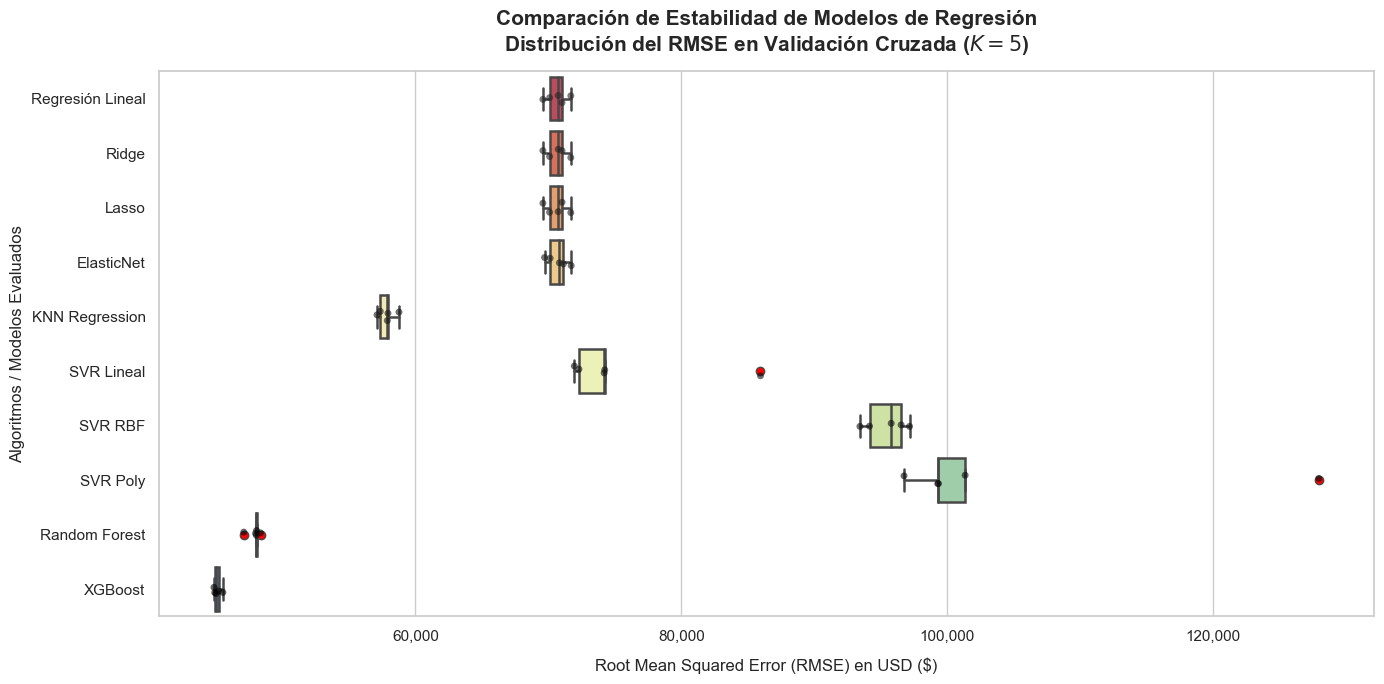

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================================
# 1. RECOLECCIÓN DE LOS SCORES DE VALIDACIÓN CRUZADA (5 FOLDS)
# =========================================================================
# Extraemos los 5 scores de cada GridSearch y los multiplicamos por -1 
# para convertirlos en RMSE positivo (valores reales en dólares)

f_lr    = -cv_scores_rl  # Viene de cross_val_score directo
f_ridge = -grid_search_ridge.cv_results_['split0_test_score'][indice_mejor_ridge], -grid_search_ridge.cv_results_['split1_test_score'][indice_mejor_ridge], -grid_search_ridge.cv_results_['split2_test_score'][indice_mejor_ridge], -grid_search_ridge.cv_results_['split3_test_score'][indice_mejor_ridge], -grid_search_ridge.cv_results_['split4_test_score'][indice_mejor_ridge]
f_lasso = -grid_search_lasso.cv_results_['split0_test_score'][indice_mejor_lasso], -grid_search_lasso.cv_results_['split1_test_score'][indice_mejor_lasso], -grid_search_lasso.cv_results_['split2_test_score'][indice_mejor_lasso], -grid_search_lasso.cv_results_['split3_test_score'][indice_mejor_lasso], -grid_search_lasso.cv_results_['split4_test_score'][indice_mejor_lasso]
f_en    = -grid_search_elastic.cv_results_['split0_test_score'][indice_mejor_elastic], -grid_search_elastic.cv_results_['split1_test_score'][indice_mejor_elastic], -grid_search_elastic.cv_results_['split2_test_score'][indice_mejor_elastic], -grid_search_elastic.cv_results_['split3_test_score'][indice_mejor_elastic], -grid_search_elastic.cv_results_['split4_test_score'][indice_mejor_elastic]
f_knn   = -grid_search_knn.cv_results_['split0_test_score'][indice_mejor_knn], -grid_search_knn.cv_results_['split1_test_score'][indice_mejor_knn], -grid_search_knn.cv_results_['split2_test_score'][indice_mejor_knn], -grid_search_knn.cv_results_['split3_test_score'][indice_mejor_knn], -grid_search_knn.cv_results_['split4_test_score'][indice_mejor_knn]
f_lin   = -grid_search_linear.cv_results_['split0_test_score'][indice_mejor_linear], -grid_search_linear.cv_results_['split1_test_score'][indice_mejor_linear], -grid_search_linear.cv_results_['split2_test_score'][indice_mejor_linear], -grid_search_linear.cv_results_['split3_test_score'][indice_mejor_linear], -grid_search_linear.cv_results_['split4_test_score'][indice_mejor_linear]
f_rbf   = -grid_search_rbf.cv_results_['split0_test_score'][indice_mejor_rbf], -grid_search_rbf.cv_results_['split1_test_score'][indice_mejor_rbf], -grid_search_rbf.cv_results_['split2_test_score'][indice_mejor_rbf], -grid_search_rbf.cv_results_['split3_test_score'][indice_mejor_rbf], -grid_search_rbf.cv_results_['split4_test_score'][indice_mejor_rbf]
f_poly  = -grid_search_poly.cv_results_['split0_test_score'][indice_mejor_poly], -grid_search_poly.cv_results_['split1_test_score'][indice_mejor_poly], -grid_search_poly.cv_results_['split2_test_score'][indice_mejor_poly], -grid_search_poly.cv_results_['split3_test_score'][indice_mejor_poly], -grid_search_poly.cv_results_['split4_test_score'][indice_mejor_poly]
f_rf    = -grid_search_rf.cv_results_['split0_test_score'][indice_mejor_rf], -grid_search_rf.cv_results_['split1_test_score'][indice_mejor_rf], -grid_search_rf.cv_results_['split2_test_score'][indice_mejor_rf], -grid_search_rf.cv_results_['split3_test_score'][indice_mejor_rf], -grid_search_rf.cv_results_['split4_test_score'][indice_mejor_rf]
f_xgb   = -grid_search_xgb.cv_results_['split0_test_score'][indice_mejor_xgb], -grid_search_xgb.cv_results_['split1_test_score'][indice_mejor_xgb], -grid_search_xgb.cv_results_['split2_test_score'][indice_mejor_xgb], -grid_search_xgb.cv_results_['split3_test_score'][indice_mejor_xgb], -grid_search_xgb.cv_results_['split4_test_score'][indice_mejor_xgb]

# =========================================================================
# 2. CONSTRUCCIÓN DEL DATAFRAME PARA SEABORN
# =========================================================================
# Convertimos las listas/arrays a un diccionario plano estructurado para graficar
data_grafico = {
    'Regresión Lineal': f_lr,
    'Ridge': f_ridge,
    'Lasso': f_lasso,
    'ElasticNet': f_en,
    'KNN Regression': f_knn,
    'SVR Lineal': f_lin,
    'SVR RBF': f_rbf,
    'SVR Poly': f_poly,
    'Random Forest': f_rf,
    'XGBoost': f_xgb
}

df_boxplot = pd.DataFrame(data_grafico)

# =========================================================================
# 3. DISEÑO Y RENDERIZADO DEL DIAGRAMA DE CAJAS
# =========================================================================
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Graficamos las cajas de forma horizontal para facilitar la lectura de los nombres
ax = sns.boxplot(
    data=df_boxplot, 
    orient="h", 
    palette="Spectral", 
    linewidth=1.8,
    flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 6} # Resalta outliers en rojo
)

# Añadimos capas de puntos (stripplot) para ver la distribución exacta de los 5 folds
sns.stripplot(data=df_boxplot, orient="h", color="black", alpha=0.6, size=5, jitter=0.1)

# Formateo de etiquetas y estética científica
plt.title('Comparación de Estabilidad de Modelos de Regresión\nDistribución del RMSE en Validación Cruzada ($K=5$)', fontsize=15, pad=15, weight='bold')
plt.xlabel('Root Mean Squared Error (RMSE) en USD ($)', fontsize=12, labelpad=10)
plt.ylabel('Algoritmos / Modelos Evaluados', fontsize=12)

# Formateamos el eje X con separadores de miles para que sea legible estadísticamente
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

### **Importancia de las variables**



===   VARIABLES MÁS IMPORTANTES (XGBOOST)      ===
                  Variable Importancia
    ocean_proximity_INLAND      0.4458
             median_income      0.2255
  population_per_household      0.0563
                 longitude      0.0489
                  latitude      0.0476
       rooms_per_household      0.0373
         bedrooms_per_room      0.0339
ocean_proximity_NEAR OCEAN      0.0329
  ocean_proximity_NEAR BAY      0.0270
        housing_median_age      0.0254
    ocean_proximity_ISLAND      0.0196


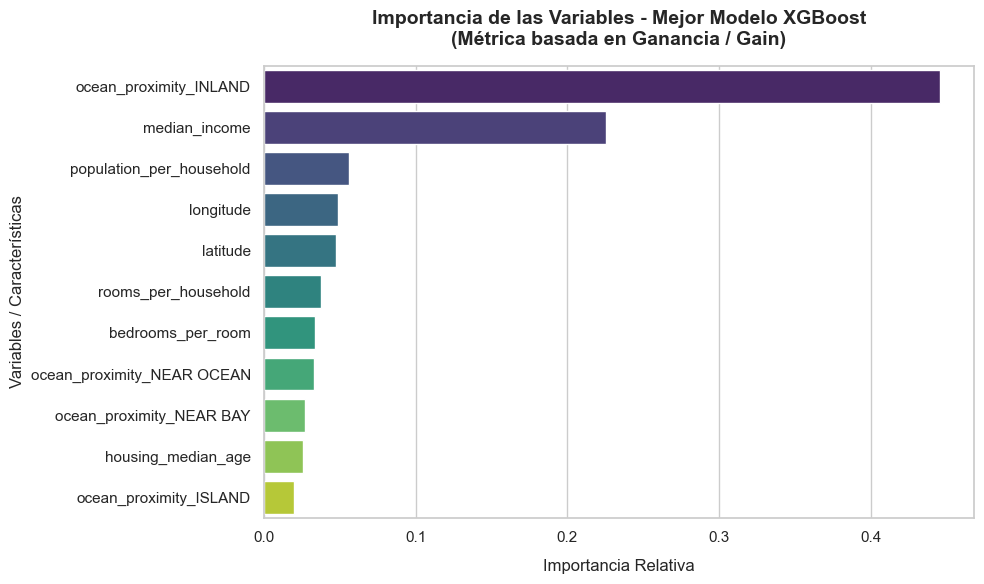

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================================================================
# 1. RECUPERAR NOMBRES DE LAS VARIABLES TRAS EL PREPROCESAMIENTO
# =========================================================================
# Extraemos el mejor modelo (pipeline) entrenado
mejor_pipeline_xgb = grid_search_xgb.best_estimator_

# Recuperamos los nombres de las columnas categóricas codificadas (OneHotEncoder)
nombres_cat = mejor_pipeline_xgb.named_steps['columntransformer'] \
                                .named_transformers_['cat'] \
                                .get_feature_names_out(col_categoricas).tolist()

# El resto de variables pasaron intactas ('passthrough'), por lo que conservan su nombre original
# Reconstruimos el orden total de la matriz que alimentó a XGBoost
todas_las_variables = nombres_cat + col_numericas

# =========================================================================
# 2. EXTRAER IMPORTANCIAS DESDE XGBOOST
# =========================================================================
# Extraemos los pesos de importancia nativos del modelo (por defecto usa 'gain')
importancias = mejor_pipeline_xgb.named_steps['xgbregressor'].feature_importances_

# Creamos un DataFrame para estructurar y ordenar los resultados
df_importancia = pd.DataFrame({
    'Variable': todas_las_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# =========================================================================
# 3. REPORTE EN CONSOLA
# =========================================================================
print("==================================================")
print("===   VARIABLES MÁS IMPORTANTES (XGBOOST)      ===")
print("==================================================")
print(df_importancia.to_string(index=False, formatters={'Importancia': '{:.4f}'.format}))

# =========================================================================
# 4. GRÁFICO DE BARRAS DE IMPORTANCIA
# =========================================================================
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(
    x='Importancia', 
    y='Variable', 
    data=df_importancia, 
    palette='viridis'
)

plt.title('Importancia de las Variables - Mejor Modelo XGBoost\n(Métrica basada en Ganancia / Gain)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Importancia Relativa', fontsize=12, labelpad=10)
plt.ylabel('Variables / Características', fontsize=12)

plt.tight_layout()
plt.show()

### **Empaquetamiento del mejor modelo**

In [74]:
import joblib

# =========================================================================
# 1. EMPAQUETAR Y GUARDAR EL MEJOR PIPELINE
# =========================================================================
# Extraemos el estimador óptimo final (el pipeline completo ya entrenado)
mejor_modelo_completo = grid_search_xgb.best_estimator_

# Definimos el nombre del archivo (usualmente se usa la extensión .pkl o .joblib)
ruta_guardado = 'mejor_modelo_xgb_pipeline.joblib'

# Guardamos el objeto en el disco duro con un nivel de compresión óptimo (3)
joblib.dump(mejor_modelo_completo, ruta_guardado, compress=3)

print("==================================================")
print(f"¡Pipeline empaquetado con éxito usando Joblib!")
print(f"Archivo guardado en: {ruta_guardado}")
print("==================================================")


# =========================================================================
# 2. CÓMO CARGAR EL MODELO EN OTRO SCRIPT (PARA PRODUCCIÓN / DESPLIEGUE)
# =========================================================================
# Imagina que este es un archivo de Python completamente nuevo (ej. app.py)

# Cargamos el pipeline con una sola línea de código
modelo_desplegado = joblib.load('mejor_modelo_xgb_pipeline.joblib')

# Para hacer predicciones, solo necesitas pasarle un DataFrame con los datos CRUDOS
# Nota: Deben ser las mismas columnas originales del X (sin transformaciones manuales)
# predicciones_nuevas = modelo_desplegado.predict(df_nuevos_datos_crudos)

¡Pipeline empaquetado con éxito usando Joblib!
Archivo guardado en: mejor_modelo_xgb_pipeline.joblib
